# 📊 8IADT TECH CHALLENGE FASE 1

Visamos construir uma solução inicial para processamento de diagnósticos dos casos de dengue, como a análise de casos graves, sintomas, semanas epidemiológica e chances de cura, utilizamos um dataset público do SUS.


 O dataset e o dicionário de dados é possivel conseguir através do link: https://dadosabertos.saude.gov.br/dataset/arboviroses-dengue

  🗄️ - **Usamos o dataset dengue-2025**


In [1]:
import pandas as pd

dados = pd.read_csv('DENGBR25.csv', sep=',')

/tmp/ipython-input-31766338.py:3: DtypeWarning: Columns (44,45,46,54,74,101) have mixed types. Specify dtype option on import or set low_memory=False.
  dados = pd.read_csv('DENGBR25.csv', sep=',')


# 🔎 Fase de pré processamento dos dados.

In [2]:
dados.shape

(1622438, 121)

### 🔎 Quantidade de registros duplicados.

In [3]:
duplicados = dados[dados.duplicated()]

qtd_duplicados = dados.duplicated().sum()
print(f"Quantidade de registros duplicados: {qtd_duplicados}")

Quantidade de registros duplicados: 649


### 🔎 Remoção de registros duplicados, que podem distorcer métricas, gerar vieses e prejudicar o modelo.

In [4]:
dados = dados.drop_duplicates()

In [5]:
dados.shape

(1621789, 121)

### 🔎 Avaliando as variáveis.

- Muitos variáveis com registros NaN, onde serão tratados um a um de acordo com sua particularidade no dicionário de dados. URL: https://s3.sa-east-1.amazonaws.com/ckan.saude.gov.br/SINAN/Dengue/dic_dados_dengue.pdf

- Variáveis com 100% de nulos em seus registros serão excluídas.

- Visando obter para análise variáveis com ≥ 70% de nulos em seus registros, na
maioria desses casos essas variáveis não agregam informação preditiva e aumentam o ruído, com exceções clínicas, por exemplo, variáveis de gravidade como: "hospitalizado" ou "obito", exames laboratoriais e sintomas como: "dores", "sangramentos" e "vomitos". Com base nesses critérios, serão feitos análises para remoção das variáveis abaixo:


In [6]:
total_linhas = len(dados)

colunas_com_muitos_nulos = []

for coluna in dados.columns:
    porcentagem_nulos = dados[coluna].isna().mean() * 100

    if porcentagem_nulos >= 70:
        colunas_com_muitos_nulos.append(coluna)
        print(f"'{coluna}' - '{porcentagem_nulos:.2f}%'")


'ID_OCUPA_N' - '72.86%'
'DT_CHIK_S1' - '99.93%'
'DT_CHIK_S2' - '100.00%'
'DT_PRNT' - '99.98%'
'RES_CHIKS1' - '99.77%'
'RES_CHIKS2' - '99.79%'
'RESUL_PRNT' - '99.78%'
'DT_SORO' - '83.75%'
'DT_VIRAL' - '99.48%'
'DT_PCR' - '96.09%'
'SOROTIPO' - '97.09%'
'DT_INTERNA' - '95.99%'
'UF' - '95.95%'
'MUNICIPIO' - '96.01%'
'DOENCA_TRA' - '100.00%'
'CLINC_CHIK' - '99.65%'
'DT_OBITO' - '99.85%'
'ALRM_HIPOT' - '97.64%'
'ALRM_PLAQ' - '97.64%'
'ALRM_VOM' - '97.64%'
'ALRM_SANG' - '97.64%'
'ALRM_HEMAT' - '97.65%'
'ALRM_ABDOM' - '97.62%'
'ALRM_LETAR' - '97.64%'
'ALRM_HEPAT' - '97.65%'
'ALRM_LIQ' - '97.65%'
'DT_ALRM' - '97.69%'
'GRAV_PULSO' - '99.81%'
'GRAV_CONV' - '99.81%'
'GRAV_ENCH' - '99.81%'
'GRAV_INSUF' - '99.81%'
'GRAV_TAQUI' - '99.81%'
'GRAV_EXTRE' - '99.81%'
'GRAV_HIPOT' - '99.81%'
'GRAV_HEMAT' - '99.81%'
'GRAV_MELEN' - '99.81%'
'GRAV_METRO' - '99.81%'
'GRAV_SANG' - '99.81%'
'GRAV_AST' - '99.81%'
'GRAV_MIOC' - '99.81%'
'GRAV_CONSC' - '99.81%'
'GRAV_ORGAO' - '99.81%'
'DT_GRAV' - '99.82%'
'MANI_HEM

### 🔎 Remoção de variáveis com valores 100% nulos em seus registros.
  - DT_CHIK_S2 = Data da coleta do soro sorológico (IgM) Chikungunya soro 2.
  - DOENCA_TRA = Indica se a doença está ou não relacionada ao trabalho.
  - MANI_HEMOR = Manifestações hemorrágicas.
  - EPISTAXE = Epistaxe.
  - GENGIVO = Gengivorrágia.
  - METRO = Metrorrágia.
  - PETEQUIAS = Petéquias.
  - HEMATURA = Hematúria.
  - SANGRAM = Sangramento Gastrointestinal.
  - LACO_N = Prova do laço positiva.
  - PLASMATICO = Houve Extravasamento Plasmático.
  - EVIDENCIA = Evidenciado por:.
  - PLAQ_MENOR = Plaquetas (Menor).
  - CON_FHD = Caso De Fhd/SCD, Especificar.
  - COMPLICA = No Caso De Dengue Com Complicações, Que Tipo De Complicações?.
  - FLXRECEBI = Identifica se o registro foi sistema recebido pelo fluxo de retorno.
  - MIGRADO_W = Identifica se o registro é oriundo da rotina de migração da base Windows

In [7]:
colunas_para_remocao = ['DT_CHIK_S2', 'DOENCA_TRA', 'MANI_HEMOR', 'EPISTAXE', 'GENGIVO', 'METRO', 'PETEQUIAS', 'HEMATURA', 'SANGRAM', 'LACO_N', 'PLASMATICO', 'EVIDENCIA', 'PLAQ_MENOR', 'CON_FHD', 'COMPLICA',
                        'FLXRECEBI', 'MIGRADO_W']

dados = dados.drop(columns=colunas_para_remocao)

### 🔎 Validando remoção das variáveis.

In [8]:
dados.shape

(1621789, 104)

### 🔎 Remoção de variáveis com valores acima de 70% de nulos em seus registros, e também por não ter o campo "ID_AGRAVO" igual a A92 ("Febre de Chikungunya")

  - DT_CHIK_S1 = Data da Coleta Exame Sorológico (IgM) Chikungunya soro 1.
  - DT_PRNT = Data da Coleta Exame PRNT.
  - RES_CHIKS1 = Resultado do Exame Sorológico (IgM) soro 1.
  - RES_CHIKS2 = Resultado do Exame Sorológico (IgM) soro 2.
  - RESUL_PRNT = Resultado do Exame Sorológico (IgM) PRNT.
  - DT_SORO = Data da Coleta Exame Sorológico (IgM) Dengue.
  - DT_VIRAL = Data da Coleta Isolamento Viral.
  - DT_PCR = Data de Coleta do Exame de RT-PCR.

In [9]:
colunas_para_remocao = ['DT_CHIK_S1', 'DT_PRNT', 'RES_CHIKS1', 'RES_CHIKS2', 'RESUL_PRNT', 'DT_SORO', 'DT_VIRAL', 'DT_PCR']

dados = dados.drop(columns=colunas_para_remocao)

### 🔎 Validando remoção das colunas.

In [10]:
dados.shape

(1621789, 96)

### 🔎 Campos numéricos (1-SIM / 2-NÃO) - Dengue Grave

  Os registros nulos serão categorizados com o valor 2(Não), conforme dicionário de dados do SUS Dengue. Apesar da maioria dos registros dessas variáveis serem nulos, invés de serem removidas, serão atualizadas, pois são variáveis sensíveis para análise de casos graves de dengue.


  - GRAV_INSUF - 99.81% nulos' = Dengue grave (Acumulo líquido insuficiência respiratória).
  - GRAV_TAQUI - 99.81% nulos = Dengue grave (taquicardia).
  - GRAV_EXTRE - 99.81% nulos = Dengue grave (Extremidade frias).
  - GRAV_HIPOT - 99.81% nulos = Dengue grave (Hipotensão arterial em fase tardia).
  - GRAV_HEMAT - 99.81% nulos = Dengue grave (Hematemese).
  - GRAV_MELEN - 99.81% nulos = Dengue grave (Melena).
  - GRAV_METRO - 99.81% nulos = Dengue grave (Metrorragia volumosa).
  - GRAV_SANG - 99.81% nulos = Dengue grave (Sangramento do SNC).
  - GRAV_AST - 99.81% nulos = Dengue grave (AST/ALT >1.000).
  - GRAV_MIOC - 99.81% nulos = Dengue grave (Miocardite).
  - GRAV_CONSC - '99.81%' nulos	= Dengue grave (Alteração de consciência).
  - GRAV_ORGAO - '99.81%' nulos	= Dengue grave (Outros orgãos).

In [11]:
colunas_numericas = ['GRAV_INSUF', 'GRAV_TAQUI', 'GRAV_EXTRE', 'GRAV_HIPOT', 'GRAV_HEMAT', 'GRAV_MELEN', 'GRAV_METRO', 'GRAV_SANG', 'GRAV_AST', 'GRAV_MIOC', 'GRAV_CONSC', 'GRAV_ORGAO']

dados[colunas_numericas] = dados[colunas_numericas].fillna(2)

### Alterando o tipo da variável ID_OCUPA_N de object para int

In [12]:
dados['ID_OCUPA_N'].dtype

dtype('O')

In [13]:
dados['ID_OCUPA_N'] = pd.to_numeric(dados['ID_OCUPA_N'], errors='coerce').astype('Int64')


### 🔎 Validando a alteração da variável "ID_OCUPA_N".

In [14]:
dados['ID_OCUPA_N'].dtype

Int64Dtype()

### 🔎 Visando obter para análise variáveis com < 70% de nulos em seus registros.

In [15]:
colunas_validas = []

for coluna in dados.columns:
    porcentagem_nulos = dados[coluna].isna().mean() * 100

    if 0.01 < porcentagem_nulos < 70:
        colunas_validas.append((coluna, porcentagem_nulos))
        print(f"'{coluna}' - '{porcentagem_nulos:.2f}%'")


'ID_REGIONA' - '3.02%'
'ANO_NASC' - '0.29%'
'CS_GESTANT' - '0.01%'
'CS_ESCOL_N' - '19.07%'
'ID_RG_RESI' - '3.05%'
'DT_INVEST' - '4.13%'
'FEBRE' - '4.13%'
'MIALGIA' - '4.13%'
'CEFALEIA' - '4.13%'
'EXANTEMA' - '4.13%'
'VOMITO' - '4.13%'
'NAUSEA' - '4.13%'
'DOR_COSTAS' - '4.13%'
'CONJUNTVIT' - '4.13%'
'ARTRITE' - '4.13%'
'ARTRALGIA' - '4.13%'
'PETEQUIA_N' - '4.13%'
'LEUCOPENIA' - '4.13%'
'LACO' - '4.13%'
'DOR_RETRO' - '4.13%'
'DIABETES' - '4.13%'
'HEMATOLOG' - '4.13%'
'HEPATOPAT' - '4.13%'
'RENAL' - '4.13%'
'HIPERTENSA' - '4.13%'
'ACIDO_PEPT' - '4.13%'
'AUTO_IMUNE' - '4.13%'
'RESUL_SORO' - '43.79%'
'DT_NS1' - '67.36%'
'RESUL_NS1' - '35.83%'
'RESUL_VI_N' - '53.88%'
'RESUL_PCR_' - '51.72%'
'HISTOPA_N' - '58.39%'
'IMUNOH_N' - '58.38%'
'HOSPITALIZ' - '24.32%'
'TPAUTOCTO' - '28.86%'
'COUFINF' - '31.58%'
'COPAISINF' - '31.58%'
'COMUNINF' - '31.81%'
'CLASSI_FIN' - '2.75%'
'CRITERIO' - '12.26%'
'EVOLUCAO' - '16.53%'
'DT_ENCERRA' - '3.46%'
'TP_SISTEMA' - '1.14%'
'DT_DIGITA' - '0.03%'


### 🔎 Variáveis clínicas. Variáveis numéricas:
  - 1 - SIM
  - 2 - NÃO
  
Os registros nulos serão categorizados com o valor 2(Não), conforme dicionário de dados do SUS Dengue.

In [16]:
campos = ['FEBRE', 'MIALGIA', 'CEFALEIA', 'EXANTEMA', 'VOMITO', 'NAUSEA', 'DOR_COSTAS', 'CONJUNTVIT', 'ARTRITE','ARTRALGIA', 'PETEQUIA_N', 'LEUCOPENIA', 'LACO', 'DOR_RETRO', 'DIABETES', 'HEMATOLOG',
                   'HEPATOPAT', 'RENAL', 'HIPERTENSA', 'ACIDO_PEPT', 'AUTO_IMUNE']

dados[campos] = dados[campos].fillna(2)

### 🔎 Variáveis de Exames. Variáveis numéricas:
  - 1 - Reagente
  - 2 - Não Reagente
  - 3 - Inconclusivo
  - 4 - Não Realizado

Os registros nulos serão categorizados com o valor 4(Não Realizado), conforme dicionário de dados do SUS Dengue.

In [17]:
campos = ['RESUL_SORO', 'RESUL_NS1', 'RESUL_VI_N', 'RESUL_PCR_', 'HISTOPA_N', 'IMUNOH_N']

dados[campos] = dados[campos].fillna(4)

### 🔎 Remoção de variáveis que não acrescentam na análise preditiva.

  - ID_REGIONA = Regional de saúde onde está localizado o município da unidade de saúde ou outra fonte notificadora.
  - CS_ESCOL_N = Série e grau que a pessoa está frequentando ou frequentou
  considerando a última série concluída com aprovação ou grau de instrução do paciente por ocasião da notificação.
  - ID_RG_RESI = Regional de saúde onde está localizado o município de residência do paciente por ocasião da notificação.
  - DT_INVEST = Data de início da investigação do caso.
  - TPAUTOCTO = Indica se o caso é autóctone do município de residência.
  - COPAISINF = País onde o paciente foi provavelmente infectado.
  - TP_SISTEMA = Identifica o sistema em que o registro foi inserido. As
  Categorias de 1 e 2 são atribuídas automaticamente.
  - DT_DIGITA = Data de Digitação da primeira inclusão da notificação no
  sistema.

### 🔎 Validando dados antes da exclusão das variáveis abaixo.

In [18]:
dados.shape

(1621789, 96)

In [19]:
campos = ['ID_REGIONA', 'CS_ESCOL_N', 'ID_RG_RESI', 'DT_INVEST', 'TPAUTOCTO', 'COPAISINF', 'TP_SISTEMA', 'DT_DIGITA']

dados = dados.drop(columns=campos)

### 🔎 Validando remoção das variáveis.

In [20]:
dados.shape

(1621789, 88)

### 🔎 A variável "ANO_NASC", possui menos de 1% de registros nulos, por ser um pequeno valor, será atualizado os valores nulos com o valor da mediana.

In [21]:
valor_mediana = dados['ANO_NASC'].median()

dados['ANO_NASC'] = dados['ANO_NASC'].fillna(valor_mediana)

### 🔎 A variável "CS_GESTANT" (Gestante), terá atualização dos registros nulos para o valor 9 (Ignorado), possui apenas 0,01% de nulos.

É uma variável numérica com os valores:
  - 1 - 1º Trimestre
  - 2 - 2º Trimestre
  - 3 - 3º Trimestre
  - 4 - Idade gestacional ignorada
  - 5 - Não
  - 6 - Não se aplica
  - 9 - Ignorado

In [22]:
dados['CS_GESTANT'] = dados['CS_GESTANT'].fillna(9)

### 🔎 A variável HOSPITALIZ (Informa se ocorreu hospitalização).

É uma variável numérica com os valores:

  - 1 - Sim
  - 2 - Não
  - 9 - Ignorado

  Possui 24% de nulos, e esses valores serão preenchidos com o valor 9 (Ignorado).

In [23]:
dados['HOSPITALIZ'] = dados['HOSPITALIZ'].fillna(9)

###🔎 Variável COUFINF (Sigla da unidade federada onde o paciente foi provavelmente infectado).

No dataset de dengue não possui a descrição, dessa forma iremos pegar o código e a descrição no site da agricultura: https://sistemasweb.agricultura.gov.br/manuais/Manual_PGA_WS/322CodigoIBGESigladaUnidadeFeder.html, colocar em um dataframe e fazer o merge com o dataset de dengue.

Essa coluna possui 30% de registros nulos, onde esses registros serão atualizados para o valor 09 (Não Informado).

In [24]:
ufs_dados = pd.DataFrame({
    'COD_UF': [
        11,12,13,14,15,16,17,
        21,22,23,24,25,26,27,28,29,
        31,32,33,35,
        41,42,43,
        50,51,52,53
    ],
    'UF_DESCRICAO': [
        'RO','AC','AM','RR','PA','AP','TO', 'MA','PI','CE','RN','PB', 'PE','AL','SE','BA', 'MG','ES','RJ','SP', 'PR','SC','RS', 'MS','MT','GO','DF'
    ]
})


In [25]:
dados = dados.merge(
    ufs_dados,
    left_on='COUFINF',
    right_on='COD_UF',
    how='left'
)


###🔎 Validando a adição dos campos "COD_UF" e "UF_DESCRIÇÂO" no dataset de dengue.

In [26]:
dados.shape

(1621789, 90)

In [27]:
dados[['COUFINF', 'COD_UF', 'UF_DESCRICAO']].head(20)


,COUFINF,COD_UF,UF_DESCRICAO
0,NaN,NaN,NaN
1,NaN,NaN,NaN
2,NaN,NaN,NaN
3,NaN,NaN,NaN
4,NaN,NaN,NaN
5,NaN,NaN,NaN
6,NaN,NaN,NaN
7,15.0,15.0,PA
8,NaN,NaN,NaN
9,NaN,NaN,NaN


###🔎 Atualizando os registros nulos da variável "COUFINF" para 9 (Não Informado) e a variável "UF_DESCRICAO" para texto "Não Informado".

In [28]:
dados['COUFINF'] = dados['COUFINF'].fillna(9)
dados['UF_DESCRICAO'] = dados['UF_DESCRICAO'].fillna('Não Informado')

###🔎 Removendo a variável "COD_UF", pois o dataset de dengue já possui a coluna "COUFINF".

In [29]:
dados.drop(columns=['COD_UF'], inplace=True)

###🔎 Validando a remoção da variável.

In [30]:
dados.shape

(1621789, 89)

###🔎 Variável COMUNINF (Código do município onde o paciente foi provavelmente infectado).

Remoção da variável devido aos inumeros municipios no Brasil, talvez poderia fazer um tratamento separando os municipios por UF e criando métricas de avaliação dos municipios com mais casos de dengue.

In [31]:
dados.drop(columns=['COMUNINF'], inplace=True)

###🔎 Validando a remoção da variável.

In [32]:
dados.shape

(1621789, 88)

### 🔎 Variável CLASSI_FIN (Classificação final do caso após investigação).

Variável numérica com os valores:
  - ‘ ‘, 0 ou 9 - Ignorado
  - 1 - Confirmado
  - 2 - Descartado
  - 8 - Inconclusivo

  Essa variável possui 3% de nulos, e os valores nulos ou com valor 0 (Zero) serão preenchidos com o valor 9 (Ignorado), visando padronizar.

In [33]:
dados['CLASSI_FIN'].dtype

dtype('float64')

In [34]:
dados['CLASSI_FIN'] = pd.to_numeric(dados['CLASSI_FIN'], errors='coerce').astype('Int64')

In [35]:
dados['CLASSI_FIN'].dtype

Int64Dtype()

In [36]:
dados.loc[
    dados['CLASSI_FIN'].isna() | (dados['CLASSI_FIN'] == 0),
    'CLASSI_FIN'
] = 9


### 🔎 Variável CRITERIO (Critério utilizado para confirmação ou descarte do caso notificado).

É uma variável numérica com os valores:

  - ‘ ‘, 0 ou 9 - Ignorado
  - 1 - Laboratório
  - 2 - Clínico-epidemiológico
  - 3 - Clínico

Essa variável possui 12% de nulos, e os valores nulos ou com valor 0 (Zero) serão preenchidos com o valor 9 (Ignorado), visando padronizar.

In [37]:
dados.loc[
    dados['CRITERIO'].isna() | (dados['CRITERIO'] == 0),
    'CRITERIO'
] = 9

### 🔎 Variável EVOLUCAO (Informar a evolução do caso).

É uma variável numérica com os valores:

  - 1 - cura
  - 2 - óbito pelo agravo
  - 3 - óbito por outras causas
  - 4 - óbito em investigação
  - 9 - ignorado

Essa variável possui 17% de nulos, tendo esses valores preenchidos com o valor 9 (Ignorado).

In [38]:
dados['EVOLUCAO'] = dados['EVOLUCAO'].fillna(9)

### 🔎  Variável DT_ENCERRA (Informar a data encerramento do caso).

Os registros nulos serão atualizados para "0000-00-00"

In [39]:
dados['DT_ENCERRA'] = dados['DT_ENCERRA'].fillna('0000-00-00')
dados['DT_ENCERRA'].head(10)

,DT_ENCERRA
0,0000-00-00
1,0000-00-00
2,0000-00-00
3,0000-00-00
4,0000-00-00
5,0000-00-00
6,0000-00-00
7,2025-03-18
8,2025-03-25
9,2025-03-11


### 🔎 Colunas para remoção, sem utilidade preditiva.

  - NU_ANO = Ano de notificação
  - ID_PAIS = País onde residia o paciente por ocasião da notificação
  - NDUPLIC_N = Identifica duplicidade
  - CS_FLXRET = Identifica se o registro está habilitado ou foi enviado pelo fluxo de retorno para o município de residência
  - DT_NSI = Data da coleta Exame Sorologia ELISA.

In [40]:
dados.shape

(1621789, 88)

In [41]:
colunas_para_remocao = ['NU_ANO', 'ID_PAIS', 'NDUPLIC_N', 'CS_FLXRET']

dados = dados.drop(columns=colunas_para_remocao)

### 🔎 Validando remoção das colunas.

In [42]:
dados.shape

(1621789, 84)

In [43]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1621789 entries, 0 to 1621788
Data columns (total 84 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   TP_NOT        1621789 non-null  int64  
 1   ID_AGRAVO     1621789 non-null  object 
 2   DT_NOTIFIC    1621789 non-null  object 
 3   SEM_NOT       1621789 non-null  int64  
 4   SG_UF_NOT     1621789 non-null  int64  
 5   ID_MUNICIP    1621789 non-null  int64  
 6   ID_UNIDADE    1621628 non-null  float64
 7   DT_SIN_PRI    1621789 non-null  object 
 8   SEM_PRI       1621789 non-null  int64  
 9   ANO_NASC      1621789 non-null  float64
 10  NU_IDADE_N    1621789 non-null  int64  
 11  CS_SEXO       1621788 non-null  object 
 12  CS_GESTANT    1621789 non-null  float64
 13  CS_RACA       1621787 non-null  float64
 14  SG_UF         1621789 non-null  int64  
 15  ID_MN_RESI    1621782 non-null  float64
 16  ID_OCUPA_N    417453 non-null   Int64  
 17  FEBRE         1621789 non-n

# 🔎 Análises de Outliers.

### Com base nas evidências abaixo, vamos analisar possíveis outliers:

  - **TP_NOT** que representa o tipo de notificação, boa parte está como 2 (Individual), no entanto tem um outlier com o valor 3 (Surto), olhando aqui não me parece um outlier, porque em algum momento deve ter tido um surto, talvez em alguma cidade ou região, vamos analisar esses dados que são importantes, no momento me parece uma distribuição normal.

  - **SEM_NOT** que representa a semana da notificação, boa parte se encontra nas semanas 10 e 20, os outliers a partir da semana 40 parece ser queda de casos, ou casos isolados, precisa-se ter uma análise melhor dessas últimas semanas do ano, no momento me parece uma distribuição normal.

  - **ANO_NASC** que representa o ano de nascimento, a maioria parece estar em 1990 a 2010 aproximadamente, tem uns outliers por volta de 1950 aproximadamente, mas não me parece ser um outlier, sendo que são anos válidos de pessoas idosas, no entanto do lado direito tem um outlier por volta do ano 2900, será que são dados de pessoas nasceram no futuro 😳 , com certeza é um erro de digitação, e veremos o tratamento desses registros, caso continuemos com essa variável.

  - **CS_GESTANT** representa a gestação, não me parece ter outlier nessa coluna, porque até o 3 são os valores que representam os trimestres de gestação e do 4 até o 9 são dados que foram ignorados a gestação, ou porque é homem, criança ou idoso(a), ou mesmo uma mulher que não está grávida, no momento me parece ser uma distribuição normal.

  - **HOSPITALIZ** representa as hospitalizações, atraves do valor 1 (Sim) é possível ver que uma pequena parte teve hospitalização, a maioria não, representada pelo valor 2 (Não), e o restante são dados que foram ignorados, representados pelo valor 9, no momento me parece ser uma distribuição normal.

  - **CRITERIO** representa os critérios utilizados como 1-(laboratório), 2-(clinico-epidemiológico), 3-(clínico) e 9-(ignorado), me parece ser uma distribuição normal.

  - **EVOLUCAO** representa e evolução do caso, 1-(cura), 2-(óbito pelo agravo), 3-(óbito por outras causas), 4-(óbito em investigação) e 9-(ignorado). A maioria dos casos tiveram cura, a outra parte foi ignorada, tem uns outliers, no entanto não parece ser outliers, e sim casos envolvendo óbito e que não está sendo possível ver no plot devido ao baixo numeros de notificações, terá uma exploração mais detalhada, sendo que é um dado muito importante, no momento parece ser uma distribuição normal.


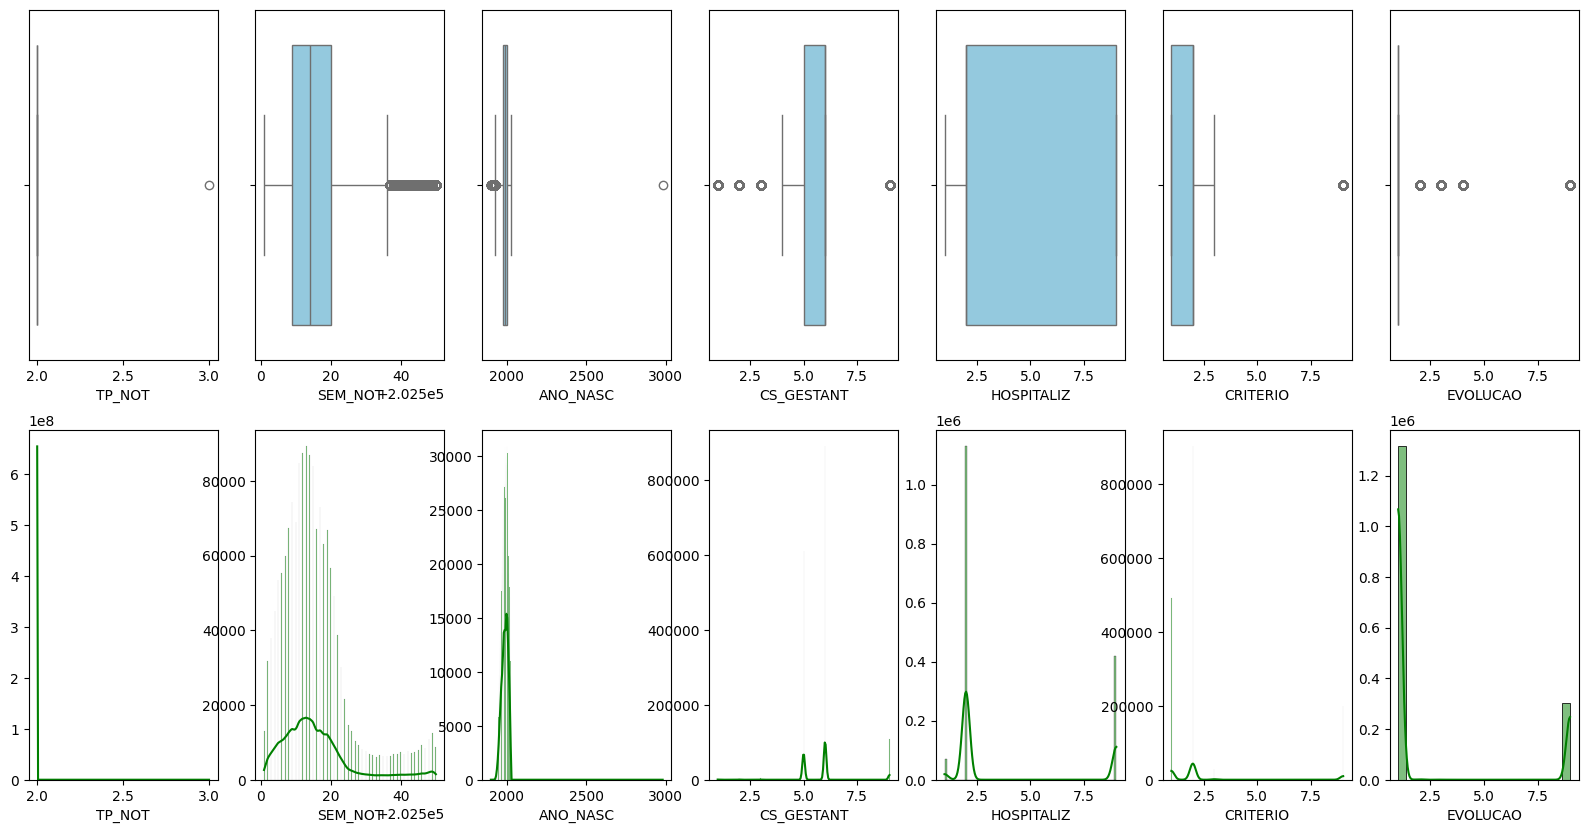

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# MONTAR BOXPLOTS PARA VERIFICAR A DISTRIBUIÇÃO E OUTLIERS
numeric_cols = ['TP_NOT', 'SEM_NOT', 'ANO_NASC', 'CS_GESTANT', 'HOSPITALIZ', 'CRITERIO', 'EVOLUCAO']

# Configurar uma grade de 2 e 8 colunas
fig, ax = plt.subplots(2, 7, figsize=(20, 10))

# Plotar os 14 gráficos
for i, col in enumerate(numeric_cols):
    # Linha 1 boxplots
    sns.boxplot(x=dados[col], ax=ax[0,i], color='skyblue')
    # Linha 2 histogramas
    sns.histplot(x=dados[col], ax=ax[1,i], color='green', kde=True)
    ax[1, i].set_ylabel('')

### 🔎 Relação de registros de dengue pelos anos de nascimentos.

  Nos idosos a relação é de queda continua, mas aqui vemos melhor os dados que aparecem no outlier, do pessoal que nasceu no futuro, vamos tratar logo mais esses dados caso continuemos com essa variável, talvez uma atualização dos registros por mediana contando esses registros como se fossem do ano de 2025.

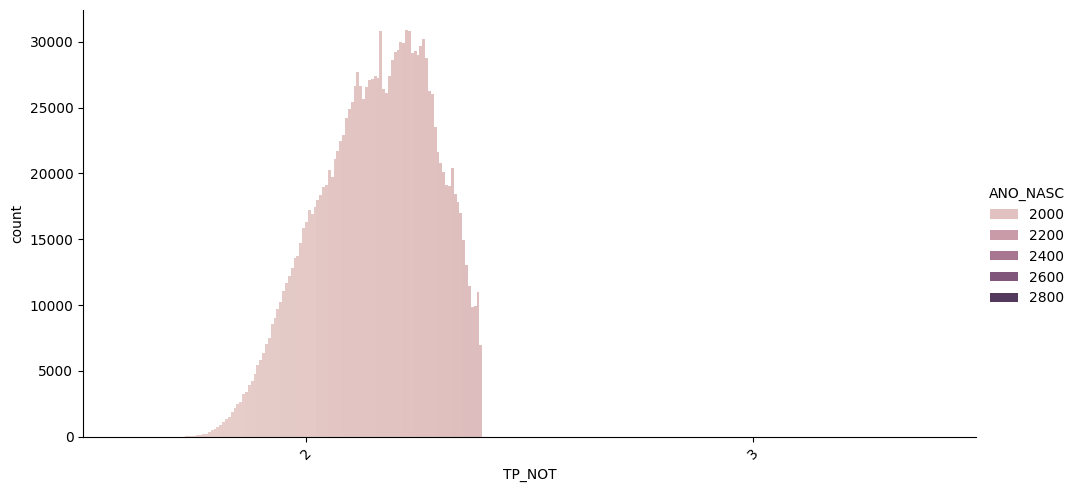

In [45]:
sns.catplot(
    data=dados,
    x="TP_NOT",
    hue="ANO_NASC",
    kind="count",
    height=5,
    aspect=2
)
plt.xticks(rotation=45)
plt.show()

### 🔎 Percentual de tipos de notificação
Abaixo conseguimos ver que 100% das notificações são do valor 2(Individuais), vimos que tinhamos outliers com o valor 3(surto), mas aqui está com 0%. Analizaremos melhor esse caso mais a frente.

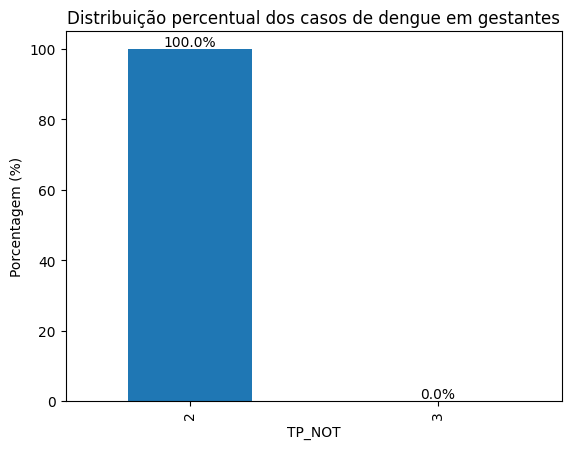

In [46]:
percentual = dados['TP_NOT'].value_counts(normalize=True) * 100

ax = percentual.plot(kind='bar')

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.ylabel('Porcentagem (%)')
plt.title('Distribuição percentual dos casos de dengue em gestantes')
plt.show()

### 🔎 Percentual de registros de dengue em gestantes.

  Aqui é possivel analisar que o número de gestantes é pequeno com o total de casos de dengue, mas é um dado importante pois pode trazer complicações na gestação, onde 1 ao 3 representa o trimestre de gestação, os demais não se enquadram a gestantes, podendo ser dados de homens, crianças, idosos(as), ou mulheres não grávidas.

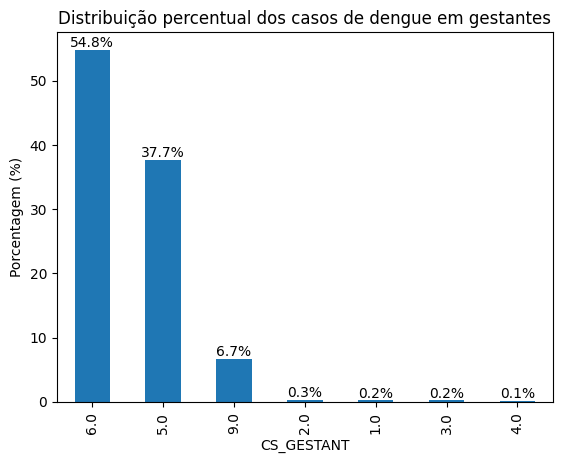

In [47]:
percentual = dados['CS_GESTANT'].value_counts(normalize=True) * 100

ax = percentual.plot(kind='bar')

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.ylabel('Porcentagem (%)')
plt.title('Distribuição percentual dos casos de dengue em gestantes')
plt.show()



### 🔎 Variável CS_SEXO (representa o sexo do paciente).

Abaixo agrupamos todos os pacientes do sexo feminino e relacionamos com a variável CS_GESTANT visando agrupar os casos de gestação, assim foi possível verificar os casos divididos quase de forma igualitária no primeiro, segundo e terceiro trimestre de gestação.

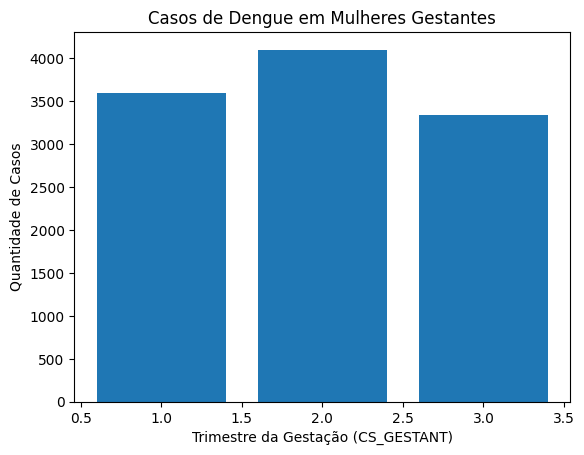

In [48]:
dados_feminino = dados[dados['CS_SEXO'] == 'F']

dados_gestantes = dados_feminino[dados_feminino['CS_GESTANT'].isin([1, 2, 3])]

contagem = (
    dados_gestantes
    .groupby('CS_GESTANT')
    .size()
    .reset_index(name='quantidade')
)

plt.figure()
plt.bar(contagem['CS_GESTANT'], contagem['quantidade'])
plt.xlabel('Trimestre da Gestação (CS_GESTANT)')
plt.ylabel('Quantidade de Casos')
plt.title('Casos de Dengue em Mulheres Gestantes')

plt.show()


### 🔎 Percentual de notificações de dengue por hospitalizações.

  Abaixo conseguimos ver que 4% dos casos notificados foram 1 (hospitalizados), 70% com valor 2 (Não foram hospitalizados) e 26% são dados não informados. Os dados de casos hospitalizados serão analisados melhor, pois são dados graves da evolução da dengue.

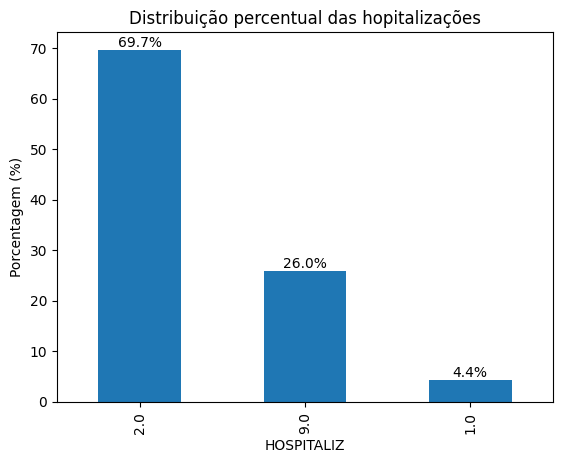

In [49]:
percentual = dados['HOSPITALIZ'].value_counts(normalize=True) * 100

ax = percentual.plot(kind='bar')

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.ylabel('Porcentagem (%)')
plt.title('Distribuição percentual das hopitalizações')
plt.show()

### 🔎 Isolando os registros 9 (Não informados), tivemos uma distribuição melhor, para que o modelo possa prever casos de hospitalização.

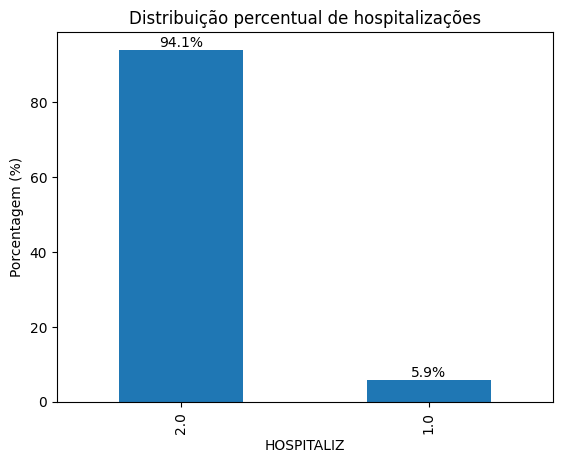

In [50]:
dados = dados[dados['HOSPITALIZ'] != 9].copy()

percentual = dados['HOSPITALIZ'].value_counts(normalize=True) * 100

ax = percentual.plot(kind='bar')

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.ylabel('Porcentagem (%)')
plt.title('Distribuição percentual de hospitalizações')
plt.show()

### 🔎 Percentual de registros da evolução do quadro de dengue.

Abaixo conseguimos analizar que 83% das notificações tiveram cura, 0,1% tiveram óbito por agravo e o restante não foi informado.

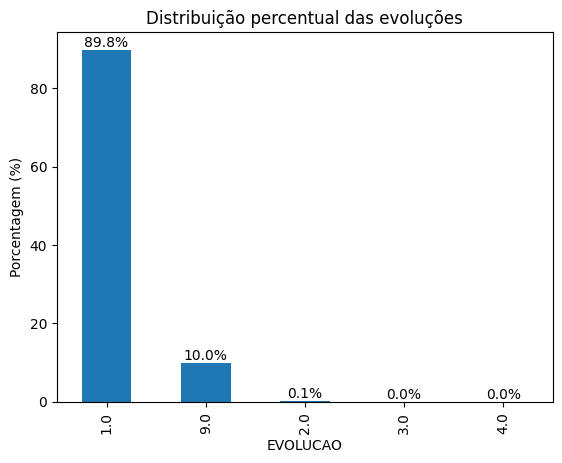

In [51]:
percentual = dados['EVOLUCAO'].value_counts(normalize=True) * 100

ax = percentual.plot(kind='bar')

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.ylabel('Porcentagem (%)')
plt.title('Distribuição percentual das evoluções')
plt.show()

### 🔎 Isolando os registros 9 (Não informados), continuamos tendo somente 0,1% dos casos graves de dengue, é bem provável que teremos dificuldade no previsão dos modelos em prever casos de óbito.

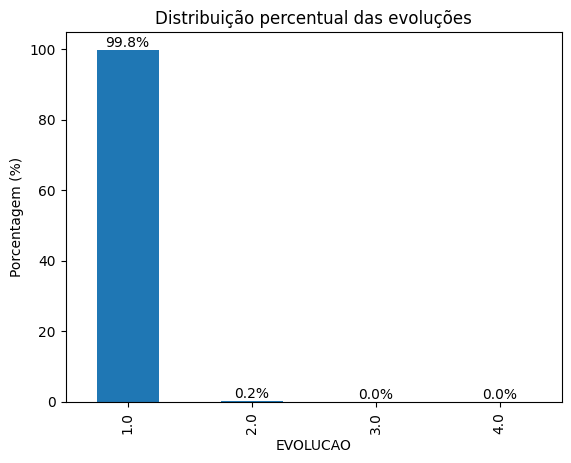

In [52]:
dados = dados[dados['EVOLUCAO'] != 9].copy()

percentual = dados['EVOLUCAO'].value_counts(normalize=True) * 100

ax = percentual.plot(kind='bar')

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.ylabel('Porcentagem (%)')
plt.title('Distribuição percentual das evoluções')
plt.show()

### 🔎 Relação dos tipos de notificações com sintomas.

  Os tipo de notificação é 2 (Individual), e abaixo está os principais sintomas relados nos quadros de dengue, sendo a maioria febre, mialgia, cefaléia, naúsea e retro orbital.


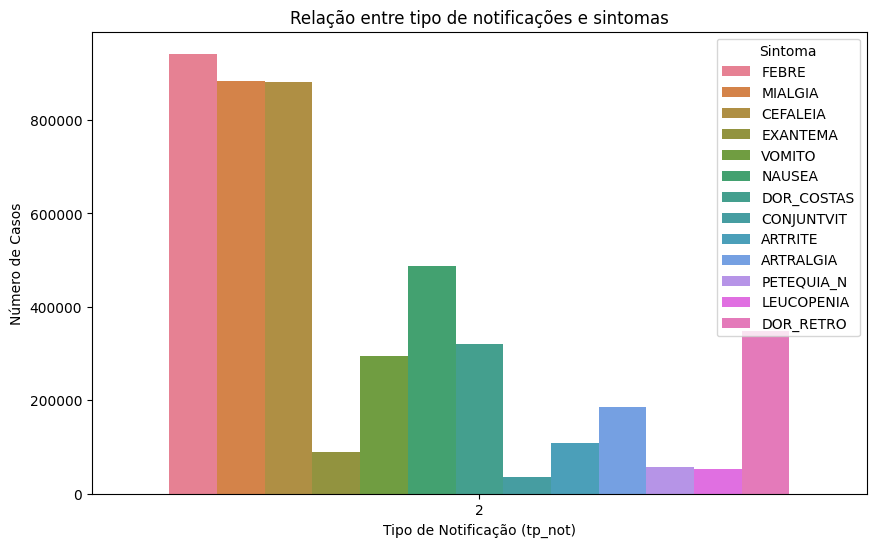

In [53]:
sintomas = ['FEBRE', 'MIALGIA', 'CEFALEIA', 'EXANTEMA', 'VOMITO', 'NAUSEA', 'DOR_COSTAS', 'CONJUNTVIT',  'ARTRITE',  'ARTRALGIA', 'PETEQUIA_N',  'LEUCOPENIA', 'DOR_RETRO']

df_plot = dados[['TP_NOT'] + sintomas].copy()

df_long = df_plot.melt(
    id_vars='TP_NOT',
    value_vars=sintomas,
    var_name='sintoma',
    value_name='presenca'
)

df_long = df_long[df_long['presenca'] == 1]

plt.figure(figsize=(10,6))
sns.countplot(
    data=df_long,
    x='TP_NOT',
    hue='sintoma'
)

plt.title('Relação entre tipo de notificações e sintomas')
plt.xlabel('Tipo de Notificação (tp_not)')
plt.ylabel('Número de Casos')
plt.legend(title='Sintoma')
plt.show()



### 🔎 Relação dos tipos de notificações com casos de dengue graves.

Abaixo nos mostra os principais quadros de sintomas, sendo eles: insuficiência respiratória, taquicardia, extremidades frias, hipertensão, alteração da consciência e agravante entre outros orgãos.

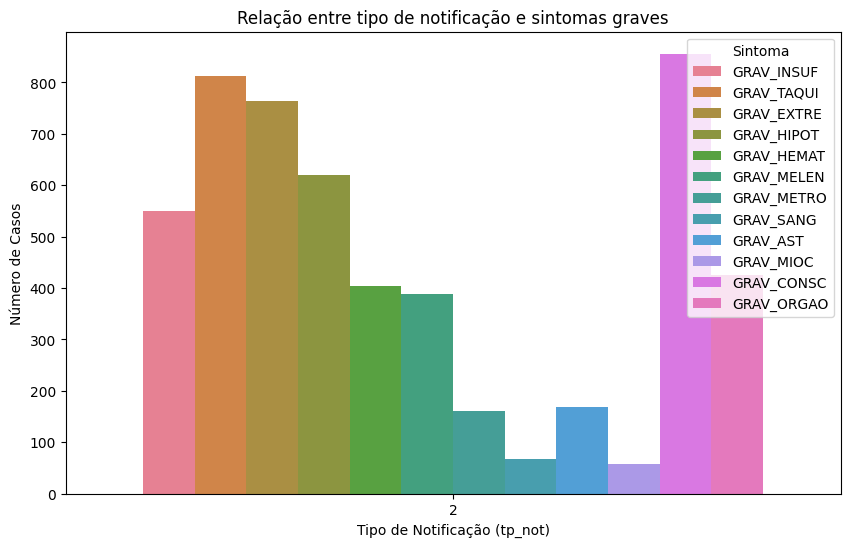

In [54]:
sintomas = ['GRAV_INSUF', 'GRAV_TAQUI', 'GRAV_EXTRE', 'GRAV_HIPOT', 'GRAV_HEMAT', 'GRAV_MELEN', 'GRAV_METRO', 'GRAV_SANG', 'GRAV_AST', 'GRAV_MIOC',  'GRAV_CONSC', 'GRAV_ORGAO']

df_plot = dados[['TP_NOT'] + sintomas].copy()

df_long = df_plot.melt(
    id_vars='TP_NOT',
    value_vars=sintomas,
    var_name='sintoma',
    value_name='presenca'
)

df_long = df_long[df_long['presenca'] == 1]

plt.figure(figsize=(10,6))
sns.countplot(
    data=df_long,
    x='TP_NOT',
    hue='sintoma'
)

plt.title('Relação entre tipo de notificação e sintomas graves')
plt.xlabel('Tipo de Notificação (tp_not)')
plt.ylabel('Número de Casos')
plt.legend(title='Sintoma')
plt.show()

### 🔎 Relação dos tipos de notificações e doenças pré existentes.

Abaixo conseguimos ver que a maioria das pessoas que foram diagnosticadas com dengue tem hipertensão e diabetes.

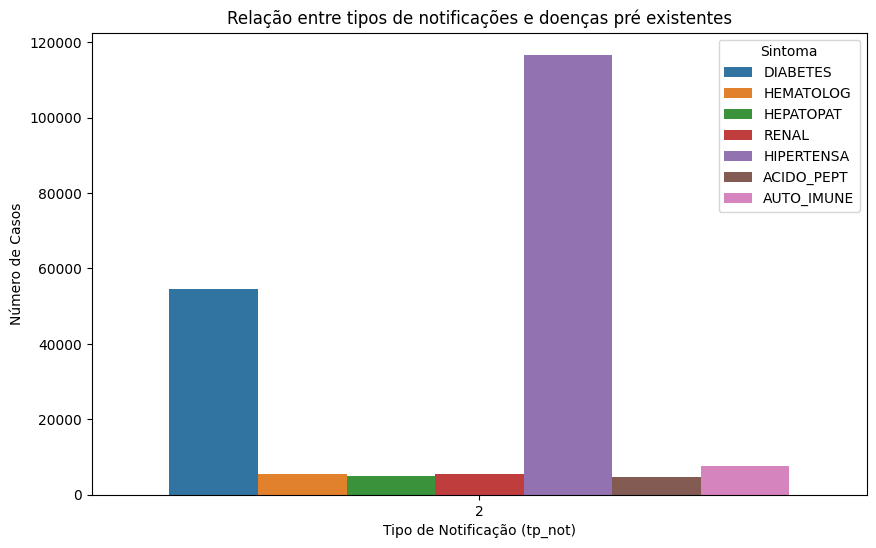

In [55]:
sintomas = ['DIABETES', 'HEMATOLOG', 'HEPATOPAT', 'RENAL', 'HIPERTENSA', 'ACIDO_PEPT', 'AUTO_IMUNE']

df_plot = dados[['TP_NOT'] + sintomas].copy()

df_long = df_plot.melt(
    id_vars='TP_NOT',
    value_vars=sintomas,
    var_name='sintoma',
    value_name='presenca'
)

df_long = df_long[df_long['presenca'] == 1]

plt.figure(figsize=(10,6))
sns.countplot(
    data=df_long,
    x='TP_NOT',
    hue='sintoma'
)

plt.title('Relação entre tipos de notificações e doenças pré existentes')
plt.xlabel('Tipo de Notificação (tp_not)')
plt.ylabel('Número de Casos')
plt.legend(title='Sintoma')
plt.show()

### 🔎 Relação dos tipos de notificações por dengue e seus exames realizados para diagnóstico.

Abaixo conseguimos ver que foram realizados em sua maioria dos exames clínicos por Soro ELISA(NS1) e Soro(IgM) Dengue.  

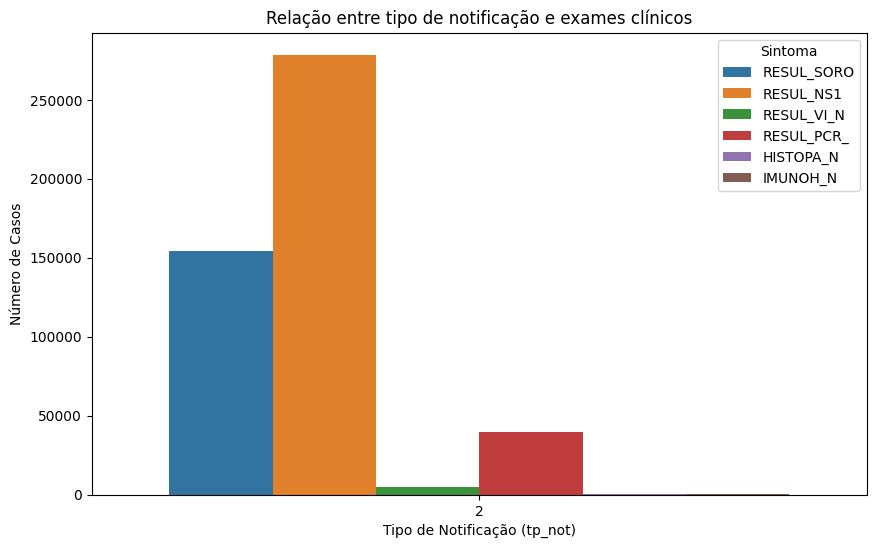

In [56]:
sintomas = ['RESUL_SORO', 'RESUL_NS1', 'RESUL_VI_N', 'RESUL_PCR_', 'HISTOPA_N', 'IMUNOH_N']

df_plot = dados[['TP_NOT'] + sintomas].copy()

df_long = df_plot.melt(
    id_vars='TP_NOT',
    value_vars=sintomas,
    var_name='sintoma',
    value_name='presenca'
)

df_long = df_long[df_long['presenca'] == 1]

plt.figure(figsize=(10,6))
sns.countplot(
    data=df_long,
    x='TP_NOT',
    hue='sintoma'
)

plt.title('Relação entre tipo de notificação e exames clínicos')
plt.xlabel('Tipo de Notificação (tp_not)')
plt.ylabel('Número de Casos')
plt.legend(title='Sintoma')
plt.show()

### 🔎 Linha de números de notificações de casos de dengue por semana.

Abaixo através da variável SEM_NOT (Semana epidemiológica que o caso foi notificado) conseguimos ver que no primeiro trimestre do ano de 2025 os números de casos de dengue são exponenciais, depois tem uma queda voltando ao ponto de casos da semana 1, onde a partir da semana 30 os casos ficam estáveis. Talvez tenha alguma relação com o clima como calor, época de chuvas ou secas dependendo das regiões, sendo que o Brasil é um país continental.

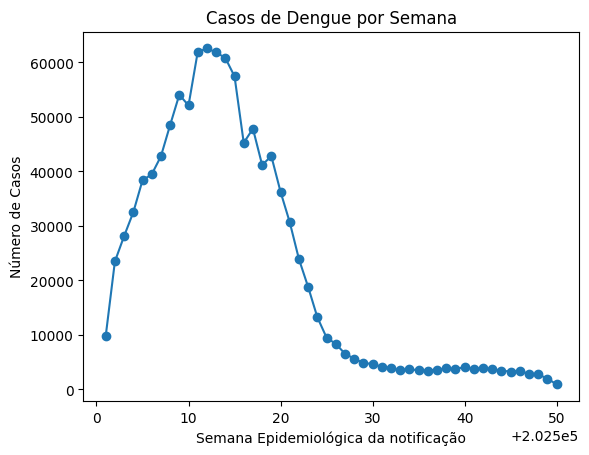

In [57]:
casos_semana = dados.groupby('SEM_NOT').size()

casos_semana.plot(kind='line', marker='o')
plt.xlabel('Semana Epidemiológica da notificação')
plt.ylabel('Número de Casos')
plt.title('Casos de Dengue por Semana')
plt.show()


### 🔎 Linha de números de casos de dengue por semana, em que o foi constatado os primeiros sintomas.

Abaixo conseguimos ver que as variáveis SEM_NOT(Gráfico acima) e SEM_PRI (Semana epidemiológica dos primeiros sintomas), andam juntas nas mesmas tendências.

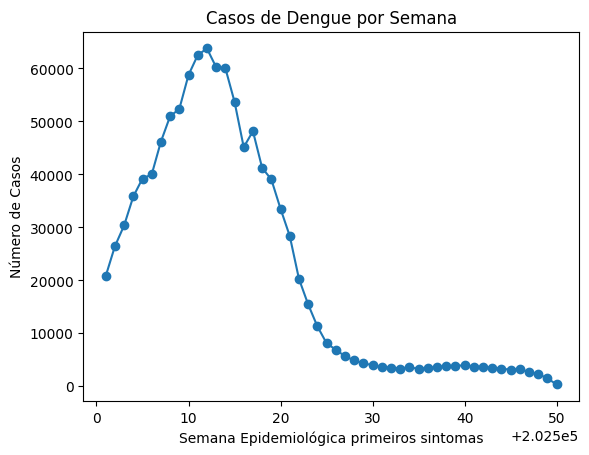

In [58]:
casos_semana = dados.groupby('SEM_PRI').size()

casos_semana.plot(kind='line', marker='o')
plt.xlabel('Semana Epidemiológica primeiros sintomas')
plt.ylabel('Número de Casos')
plt.title('Casos de Dengue por Semana')
plt.show()

### 🔎 Linha de casos de dengue por UF.

Há um pico de casos na UF 35(SP), e 9 foram dados que não foram informados, na sequência temos a 31(MG) e 52(GO).

Para ter a descrição das unidades federativas, criamos um dataframe "ufs_dados", com dados adquiridos da Secretária de Agricultura atravé do link: https://sistemasweb.agricultura.gov.br/manuais/Manual_PGA_WS/322CodigoIBGESigladaUnidadeFeder.html .

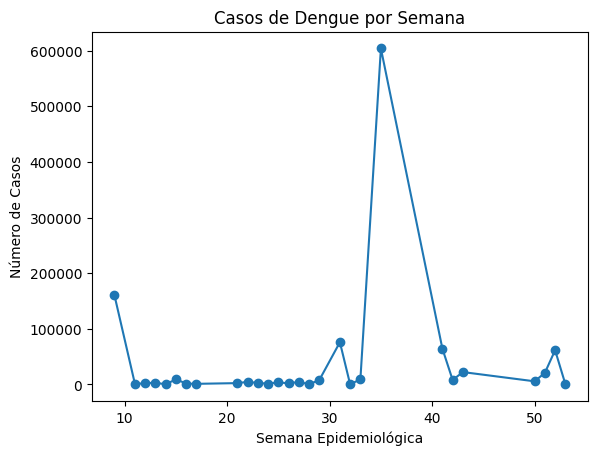

In [59]:
casos_semana = dados.groupby('COUFINF').size()

casos_semana.plot(kind='line', marker='o')
plt.xlabel('Semana Epidemiológica')
plt.ylabel('Número de Casos')
plt.title('Casos de Dengue por Semana')
plt.show()




### 🔎 Abaixo temos a porcentagem de casos de dengue por Unidade Federativa, e a mesma tendência é observada com relação ao gráfico de linhas acima.

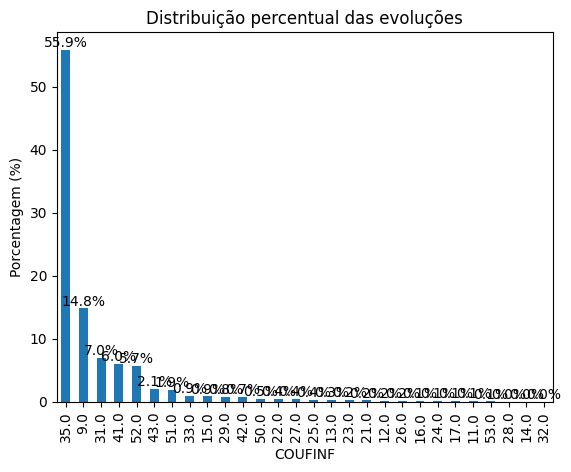

In [60]:
percentual = dados['COUFINF'].value_counts(normalize=True) * 100

ax = percentual.plot(kind='bar')

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.ylabel('Porcentagem (%)')
plt.title('Distribuição percentual das evoluções')
plt.show()

### 🔎 O gráfico acima, o segundo colocado que são os registros com valor 9 (UF's não informadas) tem 31%, um valor expressivo, vamos então isolar esses registros, para ver a distribuição e talvez ter dados mais realistas.

Como podemos ver abaixo, com a remoção dos dados 9 (Não informados), houve uma aumento de casos em todas as UF's com o aumento mais expressivo na UF 35(SP).

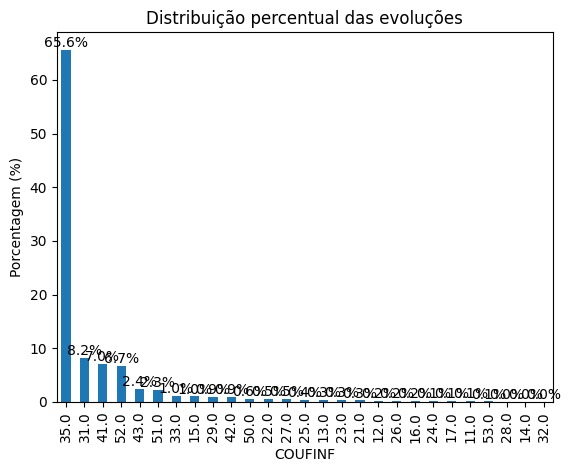

In [61]:
dados = dados[dados['COUFINF'] != 9].copy()

percentual = dados['COUFINF'].value_counts(normalize=True) * 100

ax = percentual.plot(kind='bar')

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.ylabel('Porcentagem (%)')
plt.title('Distribuição percentual das evoluções')
plt.show()

### 🔎 Remoção das variáveis abaixo que possuem valor único ou representam pouco no modelo preeditivo, visando a frente analisar a matriz de correlação com dados numéricos..

In [62]:
colunas_para_remocao = ['DT_NS1', 'TP_NOT', 'COUFINF', 'SEM_PRI', 'NU_IDADE_N', 'ID_MUNICIP', 'ID_UNIDADE', 'ID_MN_RESI', 'ID_OCUPA_N', 'ANO_NASC', 'CS_RACA', 'LACO', 'CLINC_CHIK', 'MUNICIPIO',
                        'DIABETES', 'HEMATOLOG', 'HEPATOPAT',  'RENAL', 'ACIDO_PEPT', 'AUTO_IMUNE', 'HIPERTENSA', 'RESUL_PCR_', 'RESUL_VI_N', 'SOROTIPO',
                        'HISTOPA_N', 'IMUNOH_N', 'UF', 'ID_AGRAVO', 'CS_SEXO', 'UF_DESCRICAO', 'DT_NOTIFIC', 'DT_SIN_PRI', 'DT_OBITO', 'DT_INTERNA', 'DT_ENCERRA', 'DT_ALRM', 'DT_GRAV', 'SG_UF']

dados = dados.drop(columns=colunas_para_remocao)


### 🔎 Variáveis de indicam casos graves de dengue com registros nulos, serão atualizados para 2(Não).

In [63]:
colunas_com_nulos =  ['GRAV_ENCH', 'GRAV_CONV', 'GRAV_PULSO', 'ALRM_HIPOT','ALRM_PLAQ', 'ALRM_LIQ', 'ALRM_HEPAT', 'ALRM_HEMAT', 'ALRM_SANG', 'ALRM_LETAR', 'ALRM_VOM', 'ALRM_ABDOM']

for coluna in colunas_com_nulos:
    dados[coluna] = dados[coluna].fillna(2)


In [64]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
Index: 920575 entries, 13 to 1621785
Data columns (total 46 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   SEM_NOT     920575 non-null  int64  
 1   SG_UF_NOT   920575 non-null  int64  
 2   CS_GESTANT  920575 non-null  float64
 3   FEBRE       920575 non-null  float64
 4   MIALGIA     920575 non-null  float64
 5   CEFALEIA    920575 non-null  float64
 6   EXANTEMA    920575 non-null  float64
 7   VOMITO      920575 non-null  float64
 8   NAUSEA      920575 non-null  float64
 9   DOR_COSTAS  920575 non-null  float64
 10  CONJUNTVIT  920575 non-null  float64
 11  ARTRITE     920575 non-null  float64
 12  ARTRALGIA   920575 non-null  float64
 13  PETEQUIA_N  920575 non-null  float64
 14  LEUCOPENIA  920575 non-null  float64
 15  DOR_RETRO   920575 non-null  float64
 16  RESUL_SORO  920575 non-null  float64
 17  RESUL_NS1   920575 non-null  float64
 18  HOSPITALIZ  920575 non-null  float64
 19  CLASS

# 🔎 Matriz de correlação.

### 🔎 As variáveis abaixo tem poucos dados como foi analisado nos filtros.
- Abaixo variáveis que serão removidas.

In [65]:
colunas_para_remocao = ['CLASSI_FIN', 'CRITERIO', 'SEM_NOT', 'SG_UF_NOT', 'CS_GESTANT', 'EXANTEMA',  'CONJUNTVIT', 'ARTRITE', 'PETEQUIA_N', 'LEUCOPENIA', 'GRAV_MIOC', 'GRAV_AST', 'GRAV_SANG', 'GRAV_METRO']

dados = dados.drop(columns=colunas_para_remocao)

<Axes: >

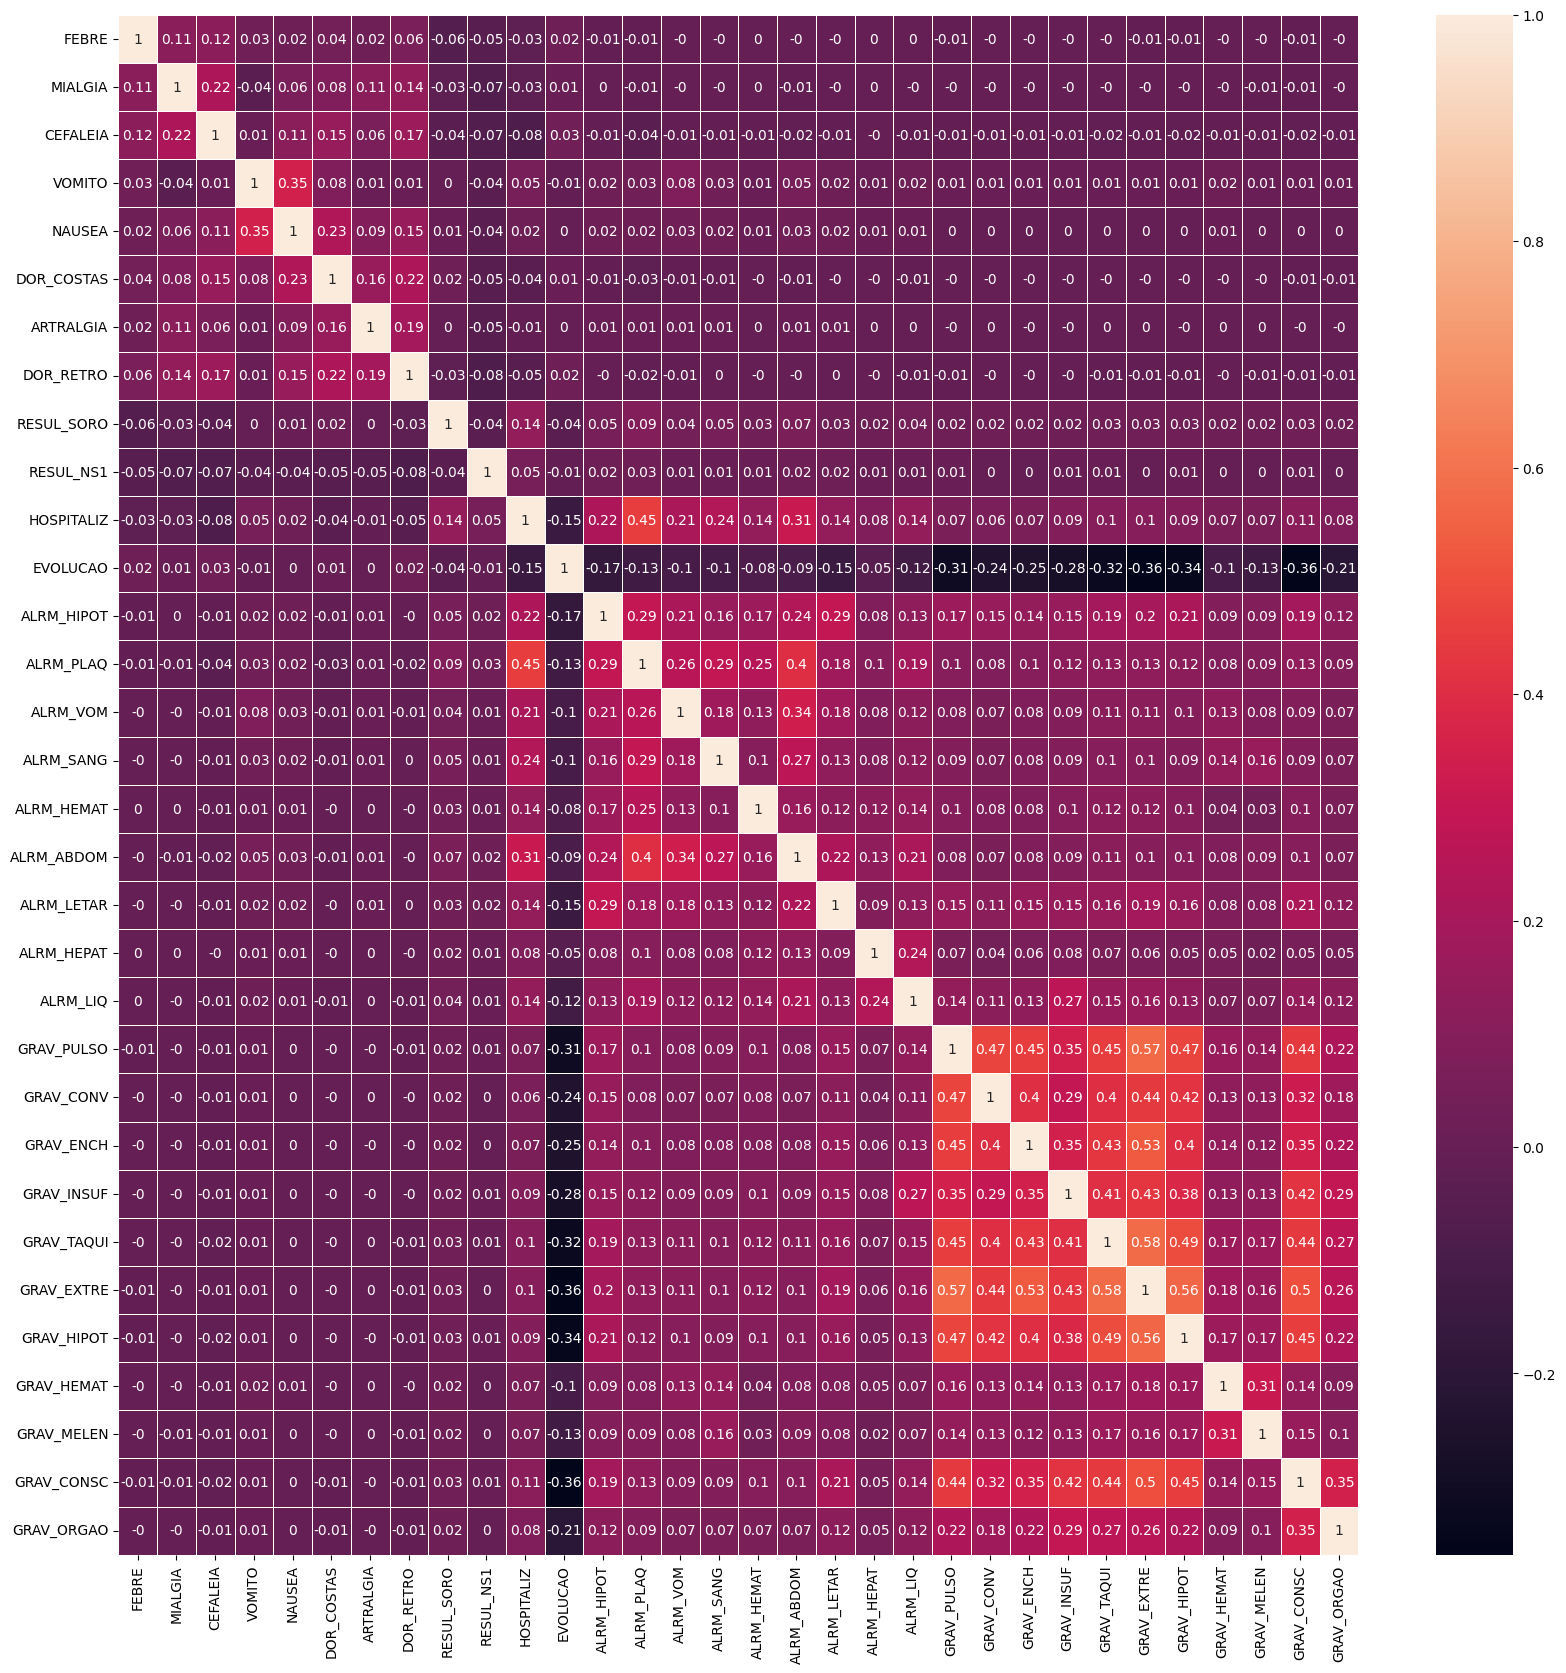

In [66]:
correlation_matrix = dados.corr().round(2)

fig, ax = plt.subplots(figsize=(20,20))
sns.heatmap(data=correlation_matrix, annot=True, linewidths=.6, ax=ax)

# 🔎  Avaliação - Matriz de correlação.

  - A colinearidade ocorre quando duas ou mais variáveis independentes estão fortemente correlacionadas entre si.

  | Tipo de variável | Situação            |
  | ---------------- | ------------------- |
  | Sintomas         | Baixa colinearidade |
  | Alarme           | Moderada            |
  | Gravidade        | Alta colinearidade  |
  | Exames           | Independentes       |


# 📌 Regressão Logística.


# 🎯 Target: EVOLUCAO (1 = cura, 2 = óbito)


In [67]:
from sklearn.compose import ColumnTransformer
features = [
    'FEBRE', 'MIALGIA', 'CEFALEIA', 'VOMITO', 'NAUSEA', 'DOR_COSTAS', 'ARTRALGIA', 'DOR_RETRO', 'RESUL_SORO', 'RESUL_NS1', 'HOSPITALIZ', 'EVOLUCAO', 'ALRM_HIPOT', 'ALRM_PLAQ', 'ALRM_VOM', 'ALRM_SANG', 'ALRM_HEMAT',
            'ALRM_ABDOM', 'ALRM_LETAR', 'ALRM_HEPAT', 'ALRM_LIQ', 'GRAV_PULSO', 'GRAV_CONV', 'GRAV_ENCH', 'GRAV_INSUF', 'GRAV_TAQUI', 'GRAV_EXTRE', 'GRAV_HIPOT', 'GRAV_HEMAT', 'GRAV_CONSC', 'GRAV_MELEN', 'GRAV_ORGAO'
]

X = dados[features]
y = dados['EVOLUCAO']


### 📌 Separar tipos de variáveis

In [68]:
from sklearn.compose import ColumnTransformer

num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns


### 📌 Pré-processamento

In [69]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])


### 📌 Split treino / teste

In [70]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [71]:
from sklearn.linear_model import LogisticRegression

log_reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        solver='liblinear'
    ))
])

log_reg.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['FEBRE', 'MIALGIA', 'CEFALEIA', 'VOMITO', 'NAUSEA', 'DOR_COSTAS',
       'ARTRALGIA', 'DOR_RETRO', 'RESUL_SORO', 'RESUL_NS1', 'HOSPITALIZ',
       'EVOLUCAO', 'ALRM_HIPOT', 'ALRM_PLAQ', 'ALRM_VOM', 'ALRM_SANG',...
       'GRAV_PULSO', 'GRAV_CONV', 'GRAV_ENCH', 'GRAV_INSUF', 'GRAV_TAQUI',
       'GRAV_EXTRE', 'GRAV_HIPOT', 'GRAV_HEMAT', 'GRAV_CONSC', 'GRAV_MELEN',
       'GRAV_ORGAO'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index([], dtype='object'))])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    solver='liblinear'))])

### 📌 Métricas

In [72]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

         1.0       1.00      1.00      1.00    183742
         2.0       0.77      1.00      0.87       287
         3.0       0.00      0.00      0.00        67
         4.0       0.00      0.00      0.00        19

    accuracy                           1.00    184115
   macro avg       0.44      0.50      0.47    184115
weighted avg       1.00      1.00      1.00    184115

[[183742      0      0      0]
 [     0    287      0      0]
 [     0     67      0      0]
 [     0     19      0      0]]


### 📌 AVALIAÇÃO

- Classe 1 (Cura), acurácia esperada, é a classe dominante, 99,8% dos registros.

- Não representa capacidade clínica.

- Classes estão extremamente desbalanceadas.

- Acurácia não valida e não sendo possível para uso clínico.

Vamos usar uma outra abordagem abaixo, com um novo pipeline com um target binário na variável "EVOLUCAO", visando verificar se conseguimos melhorar as métricas.

# 🎯  NOVO PIPELINE — TARGET BINÁRIO.

  - EVOLUCAO (SUS) ➜ EVOL_GRAVE (binário)
  - EVOLUCAO original	Novo target
      - 1 (cura) 0
      - 2 (óbito pelo agravo)	1
      - 3 (óbito outras causas)	1
      - 4 (óbito em investigação)	1

# 📌 Regressão Logística



### 📌 Filtrar dados, removendo os registros 9 (Ignorados) e criar target binário.

In [73]:
dados_bin = dados[dados['EVOLUCAO'] != 9].copy()

dados_bin['EVOL_GRAVE'] = dados_bin['EVOLUCAO'].apply(
    lambda x: 0 if x == 1 else 1
)


In [74]:
features = ['ALRM_HIPOT', 'ALRM_PLAQ', 'ALRM_VOM', 'ALRM_SANG', 'ALRM_HEMAT', 'ALRM_ABDOM', 'ALRM_LETAR', 'ALRM_HEPAT', 'ALRM_LIQ', 'GRAV_PULSO', 'GRAV_CONV', 'GRAV_ENCH', 'GRAV_INSUF', 'GRAV_TAQUI', 'GRAV_EXTRE', 'GRAV_HIPOT',
            'GRAV_HEMAT', 'GRAV_MELEN', 'GRAV_CONSC', 'GRAV_ORGAO']

X = dados_bin[features]
y = dados_bin['EVOL_GRAVE']

### 📌 Separar tipos de variáveis

In [75]:
from sklearn.compose import ColumnTransformer

num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns


### 📌 Pré-processamento

In [76]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])


### 📌 Split treino / teste

In [77]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


### 📌 Penalizamos mais os falsos negativos (classe óbito).

In [78]:
from sklearn.linear_model import LogisticRegression

log_reg_bin = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=3000,
        class_weight={0: 1, 1: 5},
        solver='liblinear'
    ))
])

LogisticRegression(
    class_weight={0:1, 1:8},
    max_iter=1000
)


log_reg_bin.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['ALRM_HIPOT', 'ALRM_PLAQ', 'ALRM_VOM', 'ALRM_SANG', 'ALRM_HEMAT',
       'ALRM_ABDOM', 'ALRM_LETAR', 'ALRM_HEPAT', 'ALRM_LIQ', 'GRAV_PULSO',
       'GRAV_CONV', 'GRAV_ENCH', 'GRAV_INSUF', 'GRAV_TAQUI', 'GRAV_EXTRE',
       'GRAV_HIPOT', 'GRAV_HEMAT', 'GRAV_MELEN', 'GRAV_CONSC', 'GRAV_ORGAO'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index([], dtype='object'))])),
                ('model',
                 LogisticRegression(class_weight={0: 1, 1: 5}, max_iter=3000,
                                    solver='liblinear'))])

### 📌 Métricas

In [79]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = log_reg_bin.predict(X_test)
y_prob = log_reg_bin.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00    183742
           1       0.67      0.47      0.55       373

    accuracy                           1.00    184115
   macro avg       0.84      0.73      0.77    184115
weighted avg       1.00      1.00      1.00    184115

AUC: 0.8558268028987961
[[183657     85]
 [   199    174]]


### 📌 AVALIAÇÃO

Como era de se imaginar o modelo não consegue prever os casos graves devido aos dados serem majoritariamente de cura.

  - Verdadeiro negativo = 183.657 registros
  - Falso positivo: 85 registros.
  - Falso negativo: 199 registros.
  - Verdadeiro positivo: 174 registros.

Na classe 0 (Cura):
  - O modelo erra mais deixando de identificar casos positivos do que classificando errado negativos, sendo bem crítico.


Na classe 1 (Óbitos):
  - O modelo acerta 67% das vezes.
  - O modelo identifica apenas 47% dos casos reais graves.
  - O modelo tem um desempenho moderado mais é penalizado pelo recall baixo.

Acurácia = 100% que é um engano, não é verdadeiro.  

AUC = 0.856 que é um ponto forte aqui, já que o modelo consegue separar bem as classes.

**- Acurácia não válida e não sendo possível para uso clínico.**

# 🎯 NOVO TARGET - Variável HOSPITALIZ

### 📌 Vamos trabalhar como target, a variável "HOSPITALIZ", que representa os casos que tiveram hospitalizações, sendo um dado importante para tomada de decisão da equipe médica para os casos graves de dengue, onde temos 6% de registros como 1 (Sim).

# 📌 Regressão Logística

In [80]:
features = [
    'FEBRE', 'MIALGIA', 'CEFALEIA', 'VOMITO', 'NAUSEA', 'DOR_COSTAS', 'ARTRALGIA', 'DOR_RETRO', 'RESUL_SORO', 'RESUL_NS1', 'EVOLUCAO', 'ALRM_HIPOT', 'ALRM_PLAQ', 'ALRM_VOM', 'ALRM_SANG', 'ALRM_HEMAT',
            'ALRM_ABDOM', 'ALRM_LETAR', 'ALRM_HEPAT', 'ALRM_LIQ', 'GRAV_PULSO', 'GRAV_CONV', 'GRAV_ENCH', 'GRAV_INSUF', 'GRAV_TAQUI', 'GRAV_EXTRE', 'GRAV_HIPOT', 'GRAV_HEMAT'
]

X = dados[features]
y = dados['HOSPITALIZ']


### 📌 Split treino / teste

In [81]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(f'O dataset de treino possui {X_train.shape[0]} linhas e {X_train.shape[1]} colunas')
print(f'O dataset de teste possui {X_test.shape[0]} linhas e {X_test.shape[1]} colunas')

scaler = StandardScaler()

X_train_escalonado = scaler.fit_transform(X_train)

X_test_escalonado = scaler.transform(X_test)

O dataset de treino possui 736460 linhas e 28 colunas
O dataset de teste possui 184115 linhas e 28 colunas


In [82]:
modelo_regressao_logistica = LogisticRegression(random_state=42)
modelo_regressao_logistica.fit(X_train_escalonado, y_train)

registro = X_train_escalonado[1:2]
hospitalizado = (
    '1 - Sim'
    if modelo_regressao_logistica.predict(registro)[0] == 1
    else '2 - Não'
)
print(f'Hospitalização: ', hospitalizado)
print(f'Chance de hospitalização {modelo_regressao_logistica.predict_proba(registro)[0][0].round(2) * 100}%')
print(f'Chance de não hospitalização {modelo_regressao_logistica.predict_proba(registro)[0][1].round(2) * 100}%')
print()

registro = X_train_escalonado[777:778]
hospitalizado = (
    '1 - Sim'
    if modelo_regressao_logistica.predict(registro)[0] == 1
    else '2 - Não'
)
print(f'Hospitalização: ', hospitalizado)
print(f'Chance de hospitalização {modelo_regressao_logistica.predict_proba(registro)[0][0].round(2) * 100}%')
print(f'Chance de não hospitalização {modelo_regressao_logistica.predict_proba(registro)[0][1].round(2) * 100}%')

print()
print(f'Score: {modelo_regressao_logistica.score(X_test_escalonado, y_test)}')


Hospitalização:  1 - Sim
Chance de hospitalização 79.0%
Chance de não hospitalização 21.0%

Hospitalização:  2 - Não
Chance de hospitalização 3.0%
Chance de não hospitalização 97.0%

Score: 0.9586399804470033


### 📌 SHAP

In [83]:
import shap

explainer = shap.LinearExplainer(modelo_regressao_logistica, X_train_escalonado)
shap_values = explainer.shap_values(X_test_escalonado)

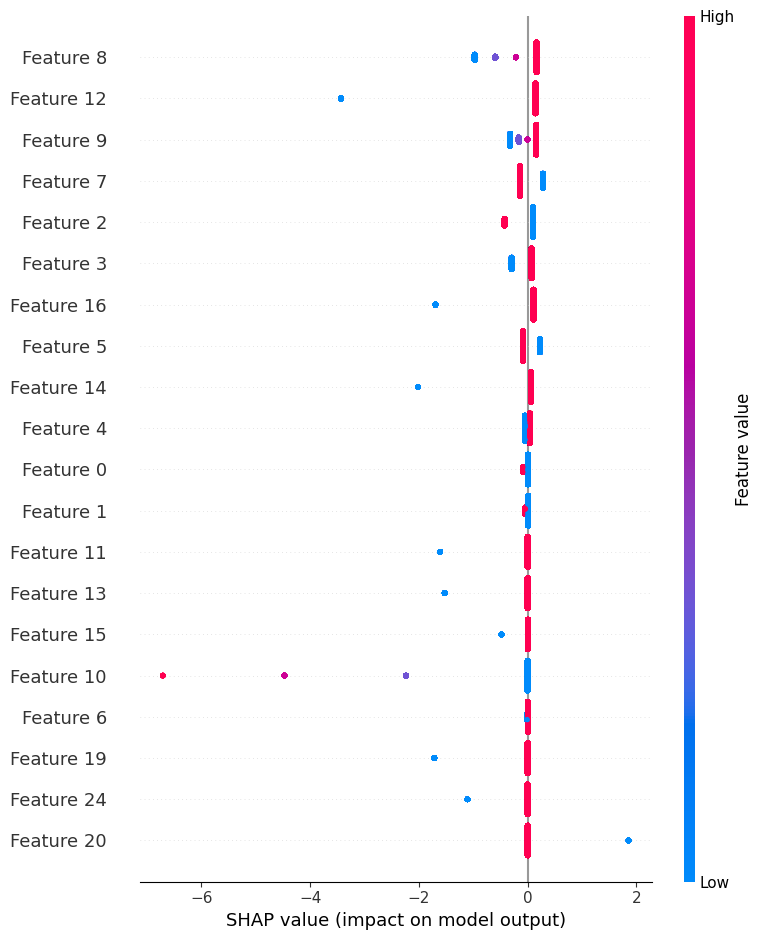

In [84]:
shap.summary_plot(shap_values, X_test_escalonado)




### 📌 Avaliação SHAP

- No eixo Y as variáveis ordenadas de cima para baixo por importância.

-No eixo X temos os valores onde:
  - Valores positivos → empurram a previsão para “classe positiva”
  - Valores negativos → empurram para “classe negativa”

- Cada ponto do gráfico representa:

  - 🔴 Vermelho: valor alto daquela feature

  - 🔵 Azul: valor baixo daquela feature

 - Interpretação:
    - Por exemplo na variável "ALRM_PLAQ", onde tem referência com plaquetas, se estiverem baixas estão associadas a maior risco a uma hospitalização.

# 📌 Floresta aleatória

In [85]:
features = [
    'FEBRE', 'MIALGIA', 'CEFALEIA', 'VOMITO', 'NAUSEA', 'DOR_COSTAS', 'ARTRALGIA', 'DOR_RETRO', 'RESUL_SORO', 'RESUL_NS1', 'EVOLUCAO', 'EVOLUCAO', 'ALRM_HIPOT', 'ALRM_PLAQ', 'ALRM_VOM', 'ALRM_SANG', 'ALRM_HEMAT',
            'ALRM_ABDOM', 'ALRM_LETAR', 'ALRM_HEPAT', 'ALRM_LIQ', 'GRAV_PULSO', 'GRAV_CONV', 'GRAV_ENCH', 'GRAV_INSUF', 'GRAV_TAQUI', 'GRAV_EXTRE', 'GRAV_HIPOT', 'GRAV_HEMAT'
]

X = dados[features]
y = dados['HOSPITALIZ']

In [86]:
X = dados.drop('HOSPITALIZ', axis=1)
y = dados['HOSPITALIZ']

X = pd.get_dummies(X, drop_first=True)


### 📌 Split treino / teste

In [87]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [88]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', min_samples_leaf=5,
                       min_samples_split=10, n_estimators=300, n_jobs=-1,
                       random_state=42)

In [89]:
registro = X_train.iloc[[1]]
hospitalizado = (
    '1 - Sim'
    if rf.predict(registro)[0] == 1
    else '2 - Não'
)
print(f'Hospitalização: ', hospitalizado)
print(f'Chance de hospitalização {rf.predict_proba(registro)[0][0].round(2) * 100}%')
print(f'Chance de não hospitalização {rf.predict_proba(registro)[0][1].round(2) * 100}%')
print()

registro = X_train.iloc[[777]]
hospitalizado = (
    '1 - Sim'
    if rf.predict(registro)[0] == 1
    else '2 - Não'
)
print(f'Hospitalização: ', hospitalizado)
print(f'Chance de hospitalização {rf.predict_proba(registro)[0][0].round(2) * 100}%')
print(f'Chance de não hospitalização {rf.predict_proba(registro)[0][1].round(2) * 100}%')

print()
print(f'Score: {rf.score(X_test, y_test)}')


Hospitalização:  1 - Sim
Chance de hospitalização 95.0%
Chance de não hospitalização 5.0%

Hospitalização:  2 - Não
Chance de hospitalização 39.0%
Chance de não hospitalização 61.0%

Score: 0.8575890068707058


## 📌 Importância por variáveis

In [90]:
importances = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importances.head(30)


,0
ALRM_PLAQ,0.334624
RESUL_SORO,0.171291
ALRM_ABDOM,0.140601
ALRM_SANG,0.061793
CEFALEIA,0.048731
ALRM_HIPOT,0.043718
RESUL_NS1,0.040990
ALRM_VOM,0.036658
DOR_RETRO,0.029068
VOMITO,0.019250


# 📌 Matriz de confusão.

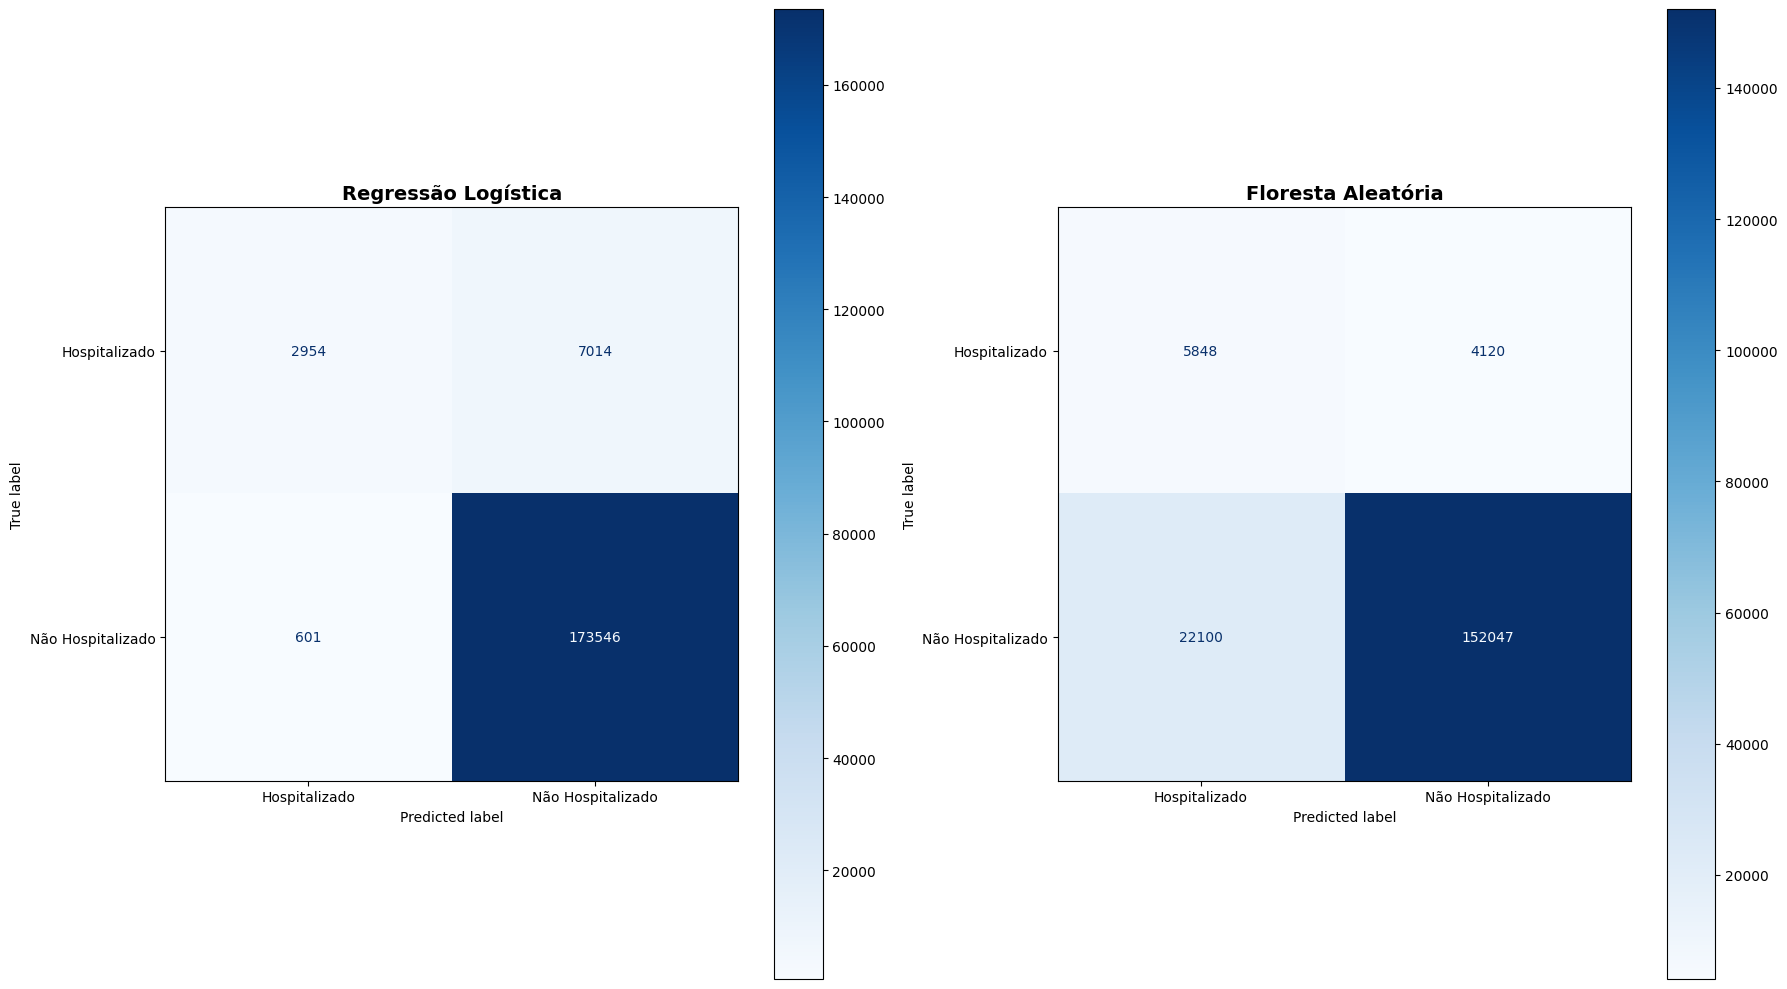

In [91]:
from sklearn.metrics import ConfusionMatrixDisplay

modelos = [modelo_regressao_logistica, rf]
modelos_nomes = ["Regressão Logística", "Floresta Aleatória"]

fig, axes = plt.subplots(1, 2, figsize=(18, 10), dpi=100)
axes = axes.flatten()

for i, modelo in enumerate(modelos):
    if "Árvore" in modelos_nomes[i] or "Floresta" in modelos_nomes[i]:
        X_avaliacao = X_test
    else:
        X_avaliacao = X_test_escalonado

    ConfusionMatrixDisplay.from_estimator(
        modelo,
        X_avaliacao,
        y_test,
        display_labels=['Hospitalizado', 'Não Hospitalizado'],
        cmap='Blues',
        ax=axes[i]
    )
    axes[i].set_title(modelos_nomes[i], fontsize=14, fontweight='bold')
    axes[i].grid(False)

plt.tight_layout()
plt.show()

### 📌 Avaliação - Matriz de confusão

  - Comparativo entre os modelos de Regressão Logística e Floresta Aleatória.

  - Eixos:

    - Vertical (True label) → Valor real.
    - Horizontal (Predicted label) → Valor previsto pelo modelo.

    | Situação          | Significado                                 |
    | ----------------- | ------------------------------------------- |
    | Superior esquerda | Hospitalizado corretamente                  |
    | Superior direita  | Hospitalizado errado (modelo disse NÃO)     |
    | Inferior esquerda | Não hospitalizado errado (modelo disse SIM) |
    | Inferior direita  | Não hospitalizado corretamente              |


  - Avaliação Regressão Logística:
    - O modelo acertou muito bem quem NÃO será hospitalizado.
    - Errou em muitos casos que deveriam ser hospitalizados.
    - O modelo deixou de identificar muitos pacientes que precisavam de internação.

  - Avaliação Floresta Aleatória:
    - O modelo detectou muito mais hospitalizações reais.
    - Aumentou o número de falsos positivos.
    - Melhorou bastante o recall da classe hospitalizado.
    - Em saúde pública, isso é o desejável.


    | Métrica                   | Regressão Logística |  Random Forest    |
    | ------------------------- | ------------------- | ----------------- |
    | Hospitalizados detectados | 2.954               |  **5.848**        |
    | Hospitalizados perdidos   | 7.014               |  **4.120**        |
    | Recall (sensibilidade)    | ❌ Baixo            | ✅ **Bem melhor** |


## - Conclusao:
   - Random Forest é superior para identificar os casos graves.
   - Random Forest gerou mais falsos alarmes, mas em saúde é melhor hospitalizar alguém sem necessidade, do que deixar de hospitalizar quem precisa.


# 📌 Curva ROC.

  - Plotar as curvas ROC dos modelos Regressão Logistica e Árvore Aleatória.

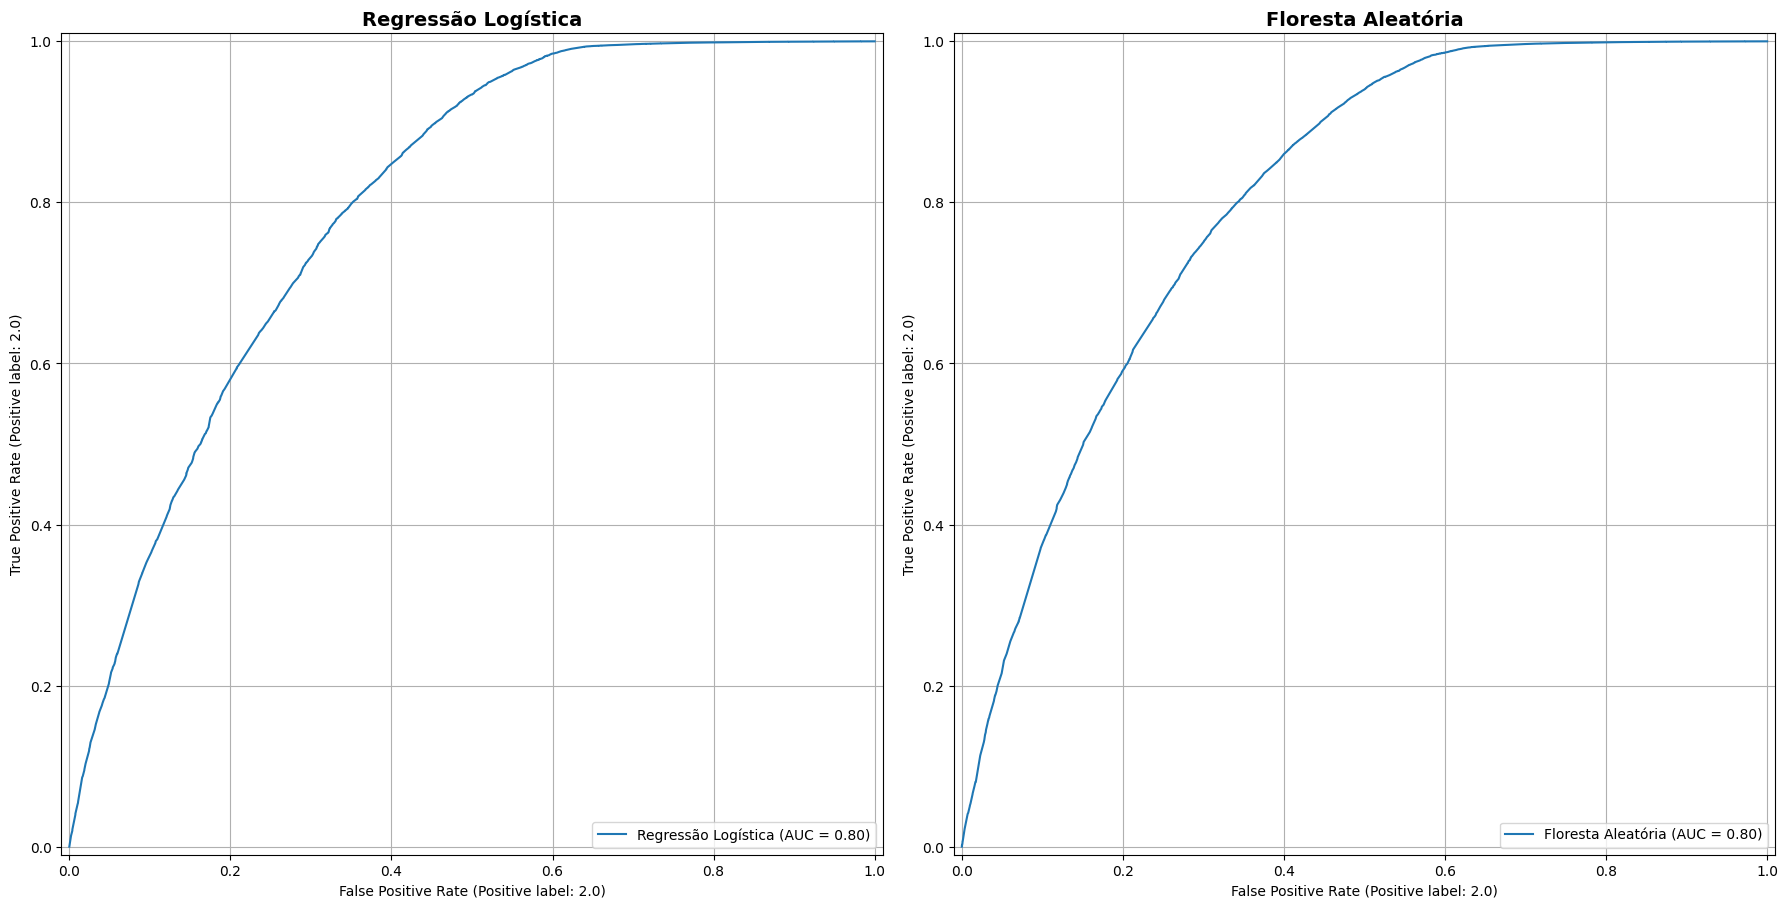

In [92]:
from sklearn.metrics import RocCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(18, 10), dpi=100)
axes = axes.flatten()

for i, modelo in enumerate(modelos):
    if "Floresta" in modelos_nomes[i]:
        X_avaliacao = X_test
    else:
        X_avaliacao = X_test_escalonado

    RocCurveDisplay.from_estimator(
        modelo,
        X_avaliacao,
        y_test,
        ax=axes[i],
        name=modelos_nomes[i]
    )
    axes[i].set_title(f'{modelos_nomes[i]}', fontsize=14, fontweight='bold')
    axes[i].grid(True)

plt.tight_layout()
plt.show()

### 📌 Avaliação - Curvas ROC.

 - A curva ROC mostra a relação entre:
    - Eixo X → False Positive Rate (falsos alarmes)
    - Eixo Y → True Positive Rate (sensibilidade / recall)


 - AUC deu o valor de 0.80 para os modelos de Regressão Logistica e Árvore Aleatória.
    - Significa que se o modelo ter um input de 1 paciente grave e 1 não grave, o modelo tem 80% de chance de dar uma probabilidade maior ao paciente grave.

  - Empate técnico em performance discriminatória.

# 📌 Validação dos modelos.

Utilizamos dois modelos na variável HOSPITALIZ como target:

  - Regressão Logistica:
    - Um modelo bom para trabalhar com probabilidades, como no nosso desafio. Qual a probabilidade de óbito pela evolução da dengue? Qual a probabilidade de hospitaização de um paciente?
    - Trabalha bem com variáveis categoricas (Sim /Não) e binárias (0/1).

  - Floresta aleatória:
    - Relações das variáveis não são lineares, como no exemplo:
      - Febre isolada → baixo risco
      - Febre + sangramento + plaquetopenia → risco alto
    - O efeito combinado entre variáveis sendo mais importante que o efeito isolado.

# 📌 Conclusão.

   - Random Forest foi superior para identificar os casos graves.
   - Random Forest gerou mais falsos alarmes, mas em saúde é melhor hospitalizar alguém sem necessidade, do que deixar de hospitalizar quem precisa.
   - Sendo um modelo clinicamente viável para os cenários de hospitalizações.

# 📌 Produtização.

In [93]:
import pickle

with open('modelo_hospitalizacao.pkl', 'wb') as file:
    pickle.dump(rf, file)

In [94]:
modelo_salvo = pickle.load(open('modelo_hospitalizacao.pkl', 'rb'))

In [95]:
registro = X_train.iloc[1]
resultado = modelo_salvo.predict(registro.to_frame().T)[0]
if resultado == 1:
    print('Sim - paciente deve ser hospitalizado!')
else:
    print('Não - paciente não deve ser hospitalizado!')
predict_proba = modelo_salvo.predict_proba(registro.to_frame().T)
print(f'Chance de hospitalização {predict_proba[0][0].round(2) * 100}%')
print(f'Chance de não hospitalização {predict_proba[0][1].round(2) * 100}%')
print()

registro = X_train.iloc[777]
resultado = modelo_salvo.predict(registro.to_frame().T)[0]
if resultado == 1:
    print('Sim - paciente deve ser hospitalizado!')
else:
    print('Não - paciente não deve ser hospitalizado!')
predict_proba = modelo_salvo.predict_proba(registro.to_frame().T)
print(f'Chance de hospitalização {predict_proba[0][0].round(2) * 100}%')
print(f'Chance de não hospitalização {predict_proba[0][1].round(2) * 100}%')


Sim - paciente deve ser hospitalizado!
Chance de hospitalização 95.0%
Chance de não hospitalização 5.0%

Não - paciente não deve ser hospitalizado!
Chance de hospitalização 39.0%
Chance de não hospitalização 61.0%
